# Prediksi Curah Hujan LSTM-PSO — Kabupaten Pasuruan
### BMKG Stasiun Geofisika Pasuruan | 2021–2025

**Skenario Pengujian:**
- **Skenario 1** — LSTM Baseline: LSTM1 (70:30) dan LSTM2 (80:20)
- **Skenario 2** — LSTM-PSO1 s/d LSTM-PSO10 (pengujian parameter PSO bertahap)
- **Skenario 3** — Perbandingan LSTM-PSO terbaik vs ARIMA, TES, GRU

## 1. Import Library

In [1]:
import os
import time
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({
    'figure.dpi'      : 150,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f9f9f9',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'font.size'       : 10
})

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('Semua library berhasil diimport.')
print(f'TensorFlow version : {tf.__version__}')

Semua library berhasil diimport.
TensorFlow version : 2.21.0


## 2. Load Data Hasil Imputasi

In [2]:
# Sesuaikan path dengan lokasi file Anda
DATA_PATH = r'd:\\rainfall-forecasting\\df_imputed.csv'
SAVE_DIR  = r'd:\\rainfall-forecasting\\output_pengujian'
CKPT_PATH = os.path.join(SAVE_DIR, 'checkpoint.pkl')  # file checkpoint
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
for col in df.columns:
    if col != 'tanggal':
        df[col] = pd.to_numeric(df[col], errors='coerce')
df.set_index('tanggal', inplace=True)

features = ['suhu', 'kelembapan', 'curah_hujan']
df = df[features].copy()

print('Informasi Data Awal (setelah imputasi):')
display(df.info())
display(df.head())
print(f'\nUkuran data     : {df.shape}')
print(f'Rentang tanggal : {df.index.min().date()} s/d {df.index.max().date()}')
print(f'Missing values  : {df.isnull().sum().to_dict()}')

Informasi Data Awal (setelah imputasi):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1815 entries, 2021-01-01 to 2025-12-31
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   suhu         1815 non-null   float64
 1   kelembapan   1815 non-null   float64
 2   curah_hujan  1815 non-null   float64
dtypes: float64(3)
memory usage: 56.7 KB


None

,suhu,kelembapan,curah_hujan
tanggal,,,
2021-01-01,21.8,93.0,19.8
2021-01-02,21.4,96.0,12.5
2021-01-03,21.4,95.0,22.1
2021-01-04,20.8,98.0,32.4
2021-01-05,20.7,98.0,15.0



Ukuran data     : (1815, 3)
Rentang tanggal : 2021-01-01 s/d 2025-12-31
Missing values  : {'suhu': 0, 'kelembapan': 0, 'curah_hujan': 0}


## 3. Verifikasi Data 

In [3]:
df_clean = df.copy()

print('Statistik deskriptif data:')
display(df_clean.describe().round(4))
print(f'\nJumlah baris : {len(df_clean)}')
print(f'Missing values: {df_clean.isnull().sum().to_dict()}')

Statistik deskriptif data:


,suhu,kelembapan,curah_hujan
count,1815.0000,1815.0000,1815.0000
mean,22.1864,87.6579,11.9970
std,1.1684,6.1340,19.8777
min,18.0000,62.0000,0.0000
25%,21.5000,84.0000,0.0000
50%,22.1000,88.2000,2.2000
75%,22.8000,92.9000,16.0700
max,29.7000,99.0000,162.0000



Jumlah baris : 1815
Missing values: {'suhu': 0, 'kelembapan': 0, 'curah_hujan': 0}


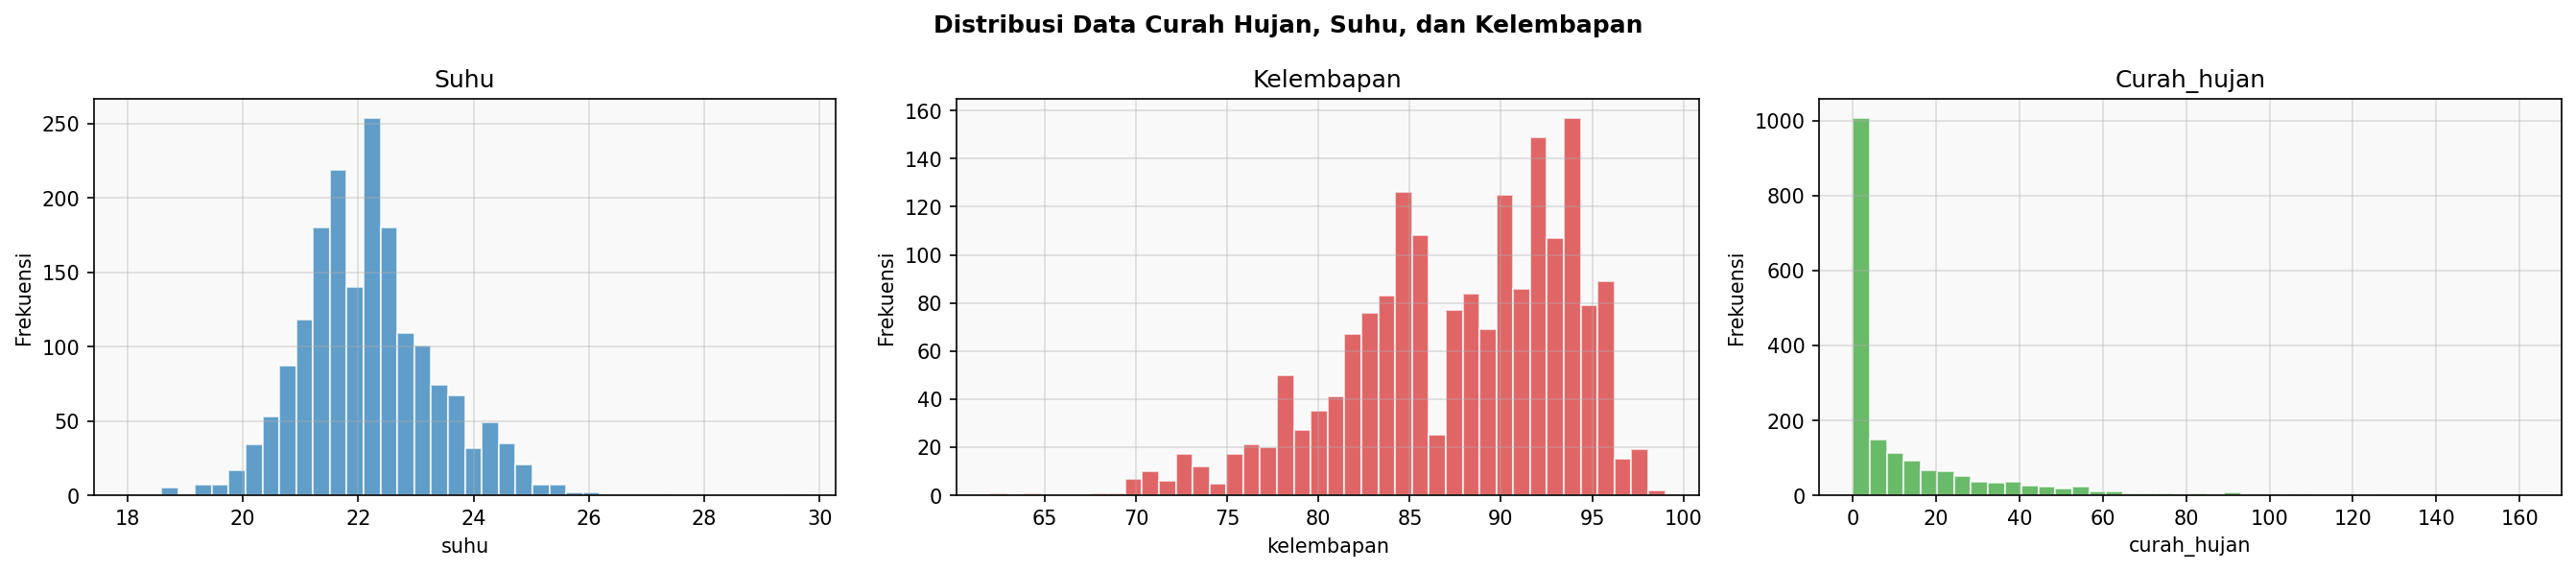

In [4]:
# Plot distribusi tiap fitur
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribusi Data Curah Hujan, Suhu, dan Kelembapan', fontsize=12, fontweight='bold')

colors = ['#1f77b4', '#d62728', '#2ca02c']
for ax, col, color in zip(axes, features, colors):
    ax.hist(df_clean[col].dropna(), bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'distribusi_data.png'), bbox_inches='tight')
plt.show()

## 4. Fungsi Checkpoint

Checkpoint disimpan sebagai file `.pkl` di `SAVE_DIR`. Setiap skenario dicek:
jika sudah tersimpan → langsung dimuat, proses PSO/training dilewati.
Jika belum → jalankan komputasi, lalu simpan hasilnya.

In [5]:
def ckpt_save(key, value):
    data = {}
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH, 'rb') as f:
            data = pickle.load(f)
    data[key] = value
    with open(CKPT_PATH, 'wb') as f:
        pickle.dump(data, f)
    print(f'  [CHECKPOINT] Disimpan: {key}')


def ckpt_load(key):

    if not os.path.exists(CKPT_PATH):
        return None
    with open(CKPT_PATH, 'rb') as f:
        data = pickle.load(f)
    return data.get(key, None)


def ckpt_exists(key):
    return ckpt_load(key) is not None


def ckpt_list():
    if not os.path.exists(CKPT_PATH):
        print('  Belum ada checkpoint.')
        return
    with open(CKPT_PATH, 'rb') as f:
        data = pickle.load(f)
    print(f'  Checkpoint ditemukan: {CKPT_PATH}')
    print(f'  Total key tersimpan : {len(data)}')
    for k in data:
        print(f'    - {k}')


print('Fungsi checkpoint berhasil didefinisikan.')
print()
ckpt_list()

Fungsi checkpoint berhasil didefinisikan.

  Checkpoint ditemukan: d:\\rainfall-forecasting\\output_pengujian\checkpoint.pkl
  Total key tersimpan : 26
    - LSTM1_70
    - LSTM2_80
    - PSO1
    - m_PSO1
    - PSO2
    - m_PSO2
    - PSO3
    - m_PSO3
    - PSO4
    - m_PSO4
    - PSO5
    - m_PSO5
    - PSO6
    - m_PSO6
    - PSO7
    - m_PSO7
    - PSO8
    - m_PSO8
    - PSO9
    - m_PSO9
    - PSO10
    - m_PSO10
    - ARIMA
    - TES
    - GRU
    - scaler


## 5. Normalisasi Data (Min-Max)

In [6]:
# Normalisasi ke rentang [0, 1]
scaler      = MinMaxScaler()
scaler.fit(df_clean[features].iloc[:int(len(df_clean)*0.8)])
data_scaled = scaler.transform(df_clean[features])

ckpt_save('scaler', scaler)

print('Contoh hasil normalisasi:')
df_norm_preview = pd.DataFrame(
    data_scaled[:5],
    columns=[f'{c}_norm' for c in features],
    index=df_clean.index[:5]
)
display(pd.concat([df_clean[features].head(), df_norm_preview], axis=1))
print(f'\nRentang nilai setelah normalisasi: [{data_scaled.min():.4f}, {data_scaled.max():.4f}]')

  [CHECKPOINT] Disimpan: scaler
Contoh hasil normalisasi:


,suhu,kelembapan,curah_hujan,suhu_norm,kelembapan_norm,curah_hujan_norm
tanggal,,,,,,
2021-01-01,21.8,93.0,19.8,0.324786,0.837838,0.122222
2021-01-02,21.4,96.0,12.5,0.290598,0.918919,0.077160
2021-01-03,21.4,95.0,22.1,0.290598,0.891892,0.136420
2021-01-04,20.8,98.0,32.4,0.239316,0.972973,0.200000
2021-01-05,20.7,98.0,15.0,0.230769,0.972973,0.092593



Rentang nilai setelah normalisasi: [0.0000, 1.0000]


## 6. Transformasi Data  (Sliding Window)

In [7]:
TIMESTEP   = 7   # 7 hari lookback
n_features = len(features)

def windowing(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i + timestep, :])
        y.append(data[i + timestep, -1])    # curah_hujan hari ke-t
    return np.array(X), np.array(y)

X, y = windowing(data_scaled, TIMESTEP)
date_all = df_clean.index[TIMESTEP:]

print(f'Timestep    : {TIMESTEP} hari')
print(f'Shape X     : {X.shape}   (samples, timestep, fitur)')
print(f'Shape y     : {y.shape}   (samples,) curah_hujan ternormalisasi')
print(f'Total sampel: {len(X)}')

df_window_preview = pd.DataFrame({
    'X': [X[i].flatten().round(3).tolist() for i in range(5)],
    'y': [round(float(y[i]), 3) for i in range(5)]
})
display(df_window_preview)


Timestep    : 7 hari
Shape X     : (1808, 7, 3)   (samples, timestep, fitur)
Shape y     : (1808,)   (samples,) curah_hujan ternormalisasi
Total sampel: 1808


,X,y
0,"[0.325, 0.838, 0.122, 0.291, 0.919, 0.077, 0.2...",0.201
1,"[0.291, 0.919, 0.077, 0.291, 0.892, 0.136, 0.2...",0.291
2,"[0.291, 0.892, 0.136, 0.239, 0.973, 0.2, 0.231...",0.006
3,"[0.239, 0.973, 0.2, 0.231, 0.973, 0.093, 0.299...",0.076
4,"[0.231, 0.973, 0.093, 0.299, 0.838, 0.343, 0.2...",0.062


In [8]:
# Membuat DataFrame lengkap hasil windowing
X_flat = X.reshape(X.shape[0], -1)

# Membuat nama kolom untuk setiap timestep
columns = []
for t in range(TIMESTEP):
    for feature in features:
        columns.append(f'{feature}_t-{TIMESTEP-t}')

# DataFrame fitur
df_complete = pd.DataFrame(X_flat, columns=columns)

# Menambahkan target dan tanggal
df_complete['target_curah_hujan'] = y
df_complete['tanggal'] = date_all

# Menyusun kolom tanggal di depan
df_complete = df_complete[['tanggal'] + columns + ['target_curah_hujan']]

# Simpan ke CSV
df_complete.to_csv('df_complete.csv', index=False)

print("File berhasil disimpan sebagai 'df_complete.csv'")
display(df_complete.head())

File berhasil disimpan sebagai 'df_complete.csv'


,tanggal,suhu_t-7,kelembapan_t-7,curah_hujan_t-7,suhu_t-6,kelembapan_t-6,curah_hujan_t-6,suhu_t-5,kelembapan_t-5,curah_hujan_t-5,...,suhu_t-3,kelembapan_t-3,curah_hujan_t-3,suhu_t-2,kelembapan_t-2,curah_hujan_t-2,suhu_t-1,kelembapan_t-1,curah_hujan_t-1,target_curah_hujan
0,2021-01-08,0.324786,0.837838,0.122222,0.290598,0.918919,0.077160,0.290598,0.891892,0.136420,...,0.230769,0.972973,0.092593,0.299145,0.837838,0.342593,0.299145,0.918919,0.163580,0.200617
1,2021-01-09,0.290598,0.918919,0.077160,0.290598,0.891892,0.136420,0.239316,0.972973,0.200000,...,0.299145,0.837838,0.342593,0.299145,0.918919,0.163580,0.299145,0.918919,0.200617,0.290741
2,2021-01-10,0.290598,0.891892,0.136420,0.239316,0.972973,0.200000,0.230769,0.972973,0.092593,...,0.299145,0.918919,0.163580,0.299145,0.918919,0.200617,0.324786,0.891892,0.290741,0.005556
3,2021-01-11,0.239316,0.972973,0.200000,0.230769,0.972973,0.092593,0.299145,0.837838,0.342593,...,0.299145,0.918919,0.200617,0.324786,0.891892,0.290741,0.367521,0.837838,0.005556,0.075926
4,2021-01-12,0.230769,0.972973,0.092593,0.299145,0.837838,0.342593,0.299145,0.918919,0.163580,...,0.324786,0.891892,0.290741,0.367521,0.837838,0.005556,0.376068,0.837838,0.075926,0.062346


## 7. Pembagian Data

In [9]:
def split_data(X, y, dates, test_size=0.2):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, shuffle=False)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.2, shuffle=False)
    n  = len(X)
    sp = int(n * (1 - test_size))
    d_te = dates[sp:]
    return X_tr, X_val, X_te, y_tr, y_val, y_te, d_te

# 70:30
X_tr70, X_val70, X_te70, y_tr70, y_val70, y_te70, d_te70 = split_data(X, y, date_all, 0.30)
# 80:20
X_tr80, X_val80, X_te80, y_tr80, y_val80, y_te80, d_te80 = split_data(X, y, date_all, 0.20)

print('=' * 55)
print('  RINGKASAN PEMBAGIAN DATA')
print('=' * 55)
print(f'  Rasio 70:30')
print(f'    Train : {X_tr70.shape[0]:4d} sampel')
print(f'    Val   : {X_val70.shape[0]:4d} sampel')
print(f'    Test  : {X_te70.shape[0]:4d} sampel')
print(f'  Rasio 80:20')
print(f'    Train : {X_tr80.shape[0]:4d} sampel')
print(f'    Val   : {X_val80.shape[0]:4d} sampel')
print(f'    Test  : {X_te80.shape[0]:4d} sampel')
print('=' * 55)

  RINGKASAN PEMBAGIAN DATA
  Rasio 70:30
    Train : 1012 sampel
    Val   :  253 sampel
    Test  :  543 sampel
  Rasio 80:20
    Train : 1156 sampel
    Val   :  290 sampel
    Test  :  362 sampel


## 8. Fungsi Helper & Evaluasi

In [10]:
def inv_ch(arr_1d):
    """Denormalisasi kolom curah_hujan (kolom terakhir scaler)."""
    arr_1d = np.asarray(arr_1d).ravel()
    dummy  = np.zeros((len(arr_1d), n_features))
    dummy[:, -1] = arr_1d
    return scaler.inverse_transform(dummy)[:, -1]


def mape_score(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error (hindari div/0)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask   = np.abs(y_true) > eps
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def nse_score(y_true, y_pred):
    """Nash-Sutcliffe Efficiency."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - np.sum((y_true - y_pred) ** 2) / denom) if denom != 0 else float('nan')


def evaluate(actual, pred, label):
    """Cetak dan kembalikan dict metrik evaluasi."""
    mae  = mean_absolute_error(actual, pred)
    rmse = float(np.sqrt(mean_squared_error(actual, pred)))
    nse  = nse_score(actual, pred)
    r2   = r2_score(actual, pred)
    print(f"  {'Metrik':<8} | {'Nilai':>12}")
    print(f"  {'-'*8}-+-{'-'*12}")
    print(f"  {'RMSE':<8} | {rmse:>12.4f}")
    print(f"  {'MAE':<8} | {mae:>12.4f}")
    print(f"  {'NSE':<8} | {nse:>12.4f}")
    print(f"  {'R²':<8} | {r2:>12.4f}")
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'NSE': nse, 'R2': r2}


def plot_loss(history, title, filename):
    """Plot learning curve loss latih vs validasi."""
    plt.figure(figsize=(12, 4))
    plt.plot(history['loss'],     label='Training Loss',   color='#1f77b4', linewidth=1.5)
    plt.plot(history['val_loss'], label='Validation Loss', color='#ff7f0e',
             linewidth=1.5, linestyle='--')
    best_ep = int(np.argmin(history['val_loss'])) + 1
    best_vl = min(history['val_loss'])
    plt.axvline(best_ep-1, color='green', linestyle=':', linewidth=1.2,
                label=f'Best epoch={best_ep} (val_loss={best_vl:.4f})')
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, filename), bbox_inches='tight')
    plt.show()


def plot_pred(dates, actual, pred_dict, title, filename):
    """Plot aktual vs prediksi."""
    plt.figure(figsize=(22, 5))
    plt.plot(dates, actual, label='Aktual', color='black',
             linewidth=1.5, linestyle='--', alpha=0.85)
    colors = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd']
    for (name, pred), color in zip(pred_dict.items(), colors):
        plt.plot(dates, pred, label=name, color=color, linewidth=1.1, alpha=0.9)
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Tanggal'); plt.ylabel('Curah Hujan (mm)')
    plt.legend(loc='upper right', fontsize=9)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, filename), bbox_inches='tight')
    plt.show()


print('Fungsi helper berhasil didefinisikan.')

Fungsi helper berhasil didefinisikan.


## 9. Arsitektur Model

In [11]:
def build_model(neurons1, neurons2, lr,
                n_steps=TIMESTEP, n_feats=n_features):
    model = Sequential()
    model.add(Input(shape=(n_steps, n_feats)))
    model.add(LSTM(int(neurons1), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(int(neurons2)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=float(lr)), loss='mse')
    return model


def build_gru(neurons, lr, n_steps=TIMESTEP, n_feats=n_features):
    model = Sequential()
    model.add(Input(shape=(n_steps, n_feats)))
    model.add(GRU(int(neurons), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=float(lr)), loss='mse')
    return model


print('Ringkasan Arsitektur LSTM Baseline (neurons1=128, neurons2=128):')
build_model(128, 128, 0.001).summary()

Ringkasan Arsitektur LSTM Baseline (neurons1=128, neurons2=128):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 128)         │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,297 (778.50 KB)

 Trainable params: 199,297 (778.50 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Fungsi Fitness & PSO

In [12]:
# Batas hyperparameter yang dioptimasi PSO
bounds = {
    'neurons1'  : (32, 256),
    'neurons2'  : (16, 128),
    'lr'        : (0.0001, 0.01),
    'batch_size': [16, 32, 64]
}


def fitness(params, X_train, y_train, X_val, y_val):
    neurons1   = int(round(params[0]))
    neurons2   = int(round(params[1]))
    lr         = float(params[2])
    batch_size = int(params[3])

    tf.keras.backend.clear_session()
    model = build_model(neurons1, neurons2, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=batch_size,
        verbose=0, callbacks=[es]
    )
    return min(history.history['val_loss'])


def init_pso(num_particles):
    particles  = []
    velocities = []
    for _ in range(num_particles):
        n1    = random.uniform(*bounds['neurons1'])
        n2    = random.uniform(*bounds['neurons2'])
        lr    = random.uniform(*bounds['lr'])
        batch = random.choice(bounds['batch_size'])
        particles.append([n1, n2, lr, batch])
        velocities.append([0, 0, 0, 0])
    particles      = np.array(particles, dtype=object)
    velocities     = np.array(velocities, dtype=object)
    pbest          = particles.copy()
    pbest_fitness  = [float('inf')] * num_particles
    gbest          = None
    gbest_fitness  = float('inf')
    return particles, velocities, pbest, pbest_fitness, gbest, gbest_fitness


def run_pso(num_particles, max_iter, w, c1, c2,
            X_train, y_train, X_val, y_val, label=''):
    particles, velocities, pbest, pbest_fitness, gbest, gbest_fitness = init_pso(num_particles)
    conv_history = []

    print(f"\n{'='*62}")
    print(f'  {label}')
    print(f'  w={w} | c1={c1} | c2={c2} | partikel={num_particles} | iterasi={max_iter}')
    print(f"{'='*62}")

    for it in range(max_iter):
        print(f'\n=== Iterasi {it+1} ===')
        for i in range(num_particles):
            f = fitness(particles[i], X_train, y_train, X_val, y_val)
            if f < pbest_fitness[i]:
                pbest[i]         = particles[i].copy()
                pbest_fitness[i] = f
            if f < gbest_fitness:
                gbest         = particles[i].copy()
                gbest_fitness = f
            print(f'  Particle {i+1:>2} | N1={int(particles[i][0]):>3} N2={int(particles[i][1]):>3} '
                  f'LR={float(particles[i][2]):.5f} Batch={int(particles[i][3]):>2} | val_loss={f:.5f}')

        for i in range(num_particles):
            for d in range(3):
                r1 = random.random(); r2 = random.random()
                velocities[i][d] = (
                    w * velocities[i][d]
                    + c1 * r1 * (float(pbest[i][d]) - float(particles[i][d]))
                    + c2 * r2 * (float(gbest[d])    - float(particles[i][d]))
                )
                particles[i][d] = float(particles[i][d]) + velocities[i][d]
            particles[i][0] = np.clip(float(particles[i][0]), *bounds['neurons1'])
            particles[i][1] = np.clip(float(particles[i][1]), *bounds['neurons2'])
            particles[i][2] = np.clip(float(particles[i][2]), *bounds['lr'])
            if random.random() < 0.3:
                particles[i][3] = random.choice(bounds['batch_size'])

        conv_history.append(gbest_fitness)
        print(f'  Global Best so far: N1={int(gbest[0])} N2={int(gbest[1])} '
              f'LR={float(gbest[2]):.5f} Batch={int(gbest[3])} Fitness={gbest_fitness:.5f}')

    print(f'\n=== Hasil Akhir ===')
    print(f'  Best Hyperparameters: N1={int(gbest[0])}, N2={int(gbest[1])}, '
          f'LR={float(gbest[2]):.6f}, Batch={int(gbest[3])}')
    print(f'  Best Fitness (val_loss): {gbest_fitness:.5f}')
    return gbest, gbest_fitness, conv_history


def train_best_model(gbest, X_tr, y_tr, X_val, y_val, X_te, y_te,
                     d_te, actual_mm, scenario_name, filename_prefix):
    n1    = int(gbest[0]);  n2    = int(gbest[1])
    lr    = float(gbest[2]); batch = int(gbest[3])
    print(f'\n>> Melatih LSTM utama: N1={n1}, N2={n2}, LR={lr:.6f}, Batch={batch}')

    tf.keras.backend.clear_session()
    model = build_model(n1, n2, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=batch,
        verbose=1, callbacks=[es]
    )

    model_path = os.path.join(SAVE_DIR, f"{filename_prefix}_model.keras")
    model.save(model_path)
    print(f'  Model disimpan: {model_path}')
    
    best_ep = int(np.argmin(history.history['val_loss'])) + 1
    best_vl = min(history.history['val_loss'])
    print(f'  Nilai validation loss terkecil pada epoch ke-{best_ep}: {best_vl:.4f}')

    # Simpan history sebagai dict (pickle-able)
    hist_dict = {k: list(v) for k, v in history.history.items()}

    plot_loss(hist_dict,
              f'Grafik Training & Validation Loss {scenario_name}',
              f'{filename_prefix}_loss.png')

    pred_mm = inv_ch(model.predict(X_te, verbose=0).ravel())
    plot_pred(d_te, actual_mm, {scenario_name: pred_mm},
              f'Grafik Aktual vs Prediksi {scenario_name}',
              f'{filename_prefix}_pred.png')

    print(f'\nMetrik Evaluasi {scenario_name}:')
    m = evaluate(actual_mm, pred_mm, scenario_name)
    return m, pred_mm, hist_dict


results_all = []
pso_log     = []
timing      = {}

print('Fungsi PSO dan training berhasil didefinisikan.')

Fungsi PSO dan training berhasil didefinisikan.



## Skenario 1  (LSTM Baseline)

| Parameter | Nilai |
|---|---|
| Neuron | 128 (kedua layer) |
| Learning Rate | 0.001 |
| Batch Size | 16 |
| Epoch | 100 |
| Dropout | 0.2 |
| Timestep | 7 |

### Skenario LSTM1  70:30

In [13]:
print('=' * 55)
print('  SKENARIO LSTM1 — Pembagian Data 70:30')
print('=' * 55)

actual_70mm = inv_ch(y_te70)

# ── CHECKPOINT: Load jika sudah ada ──
ckpt_bl70 = ckpt_load('LSTM1_70')
if ckpt_bl70:
    print('  [CHECKPOINT] LSTM1 (70:30) dimuat dari checkpoint, training dilewati.')
    hist_bl70  = ckpt_bl70['history']
    pred_bl70  = ckpt_bl70['pred']
    m_bl70     = ckpt_bl70['metrics']
    timing['LSTM1 (70:30)'] = ckpt_bl70['time']
else:
    tf.keras.backend.clear_session()
    model_bl = build_model(128, 128, 0.001)
    model_bl.summary()
    t0 = time.time()
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    _hist = model_bl.fit(
        X_tr70, y_tr70, epochs=100, batch_size=16,
        validation_data=(X_val70, y_val70), verbose=1,
        callbacks=[es]
    )
    timing['LSTM1 (70:30)'] = time.time() - t0
    hist_bl70 = {k: list(v) for k, v in _hist.history.items()}
    pred_bl70 = inv_ch(model_bl.predict(X_te70, verbose=0).ravel())
    m_bl70    = evaluate(actual_70mm, pred_bl70, 'LSTM1 (70:30)')
    # ── Simpan checkpoint ──
    ckpt_save('LSTM1_70', {
        'history': hist_bl70, 'pred': pred_bl70,
        'metrics': m_bl70,    'time': timing['LSTM1 (70:30)']
    })

results_all.append(m_bl70)
best_ep = int(np.argmin(hist_bl70['val_loss'])) + 1
best_vl = min(hist_bl70['val_loss'])
print(f'\nNilai validation loss terkecil pada epoch ke-{best_ep}: {best_vl:.4f}')
print(f'Data latih   : {X_tr70.shape[0]} sampel')
print(f'Data validasi: {X_val70.shape[0]} sampel')
print(f'Data uji     : {X_te70.shape[0]} sampel')

  SKENARIO LSTM1 — Pembagian Data 70:30
  [CHECKPOINT] LSTM1 (70:30) dimuat dari checkpoint, training dilewati.

Nilai validation loss terkecil pada epoch ke-27: 0.0144
Data latih   : 1012 sampel
Data validasi: 253 sampel
Data uji     : 543 sampel


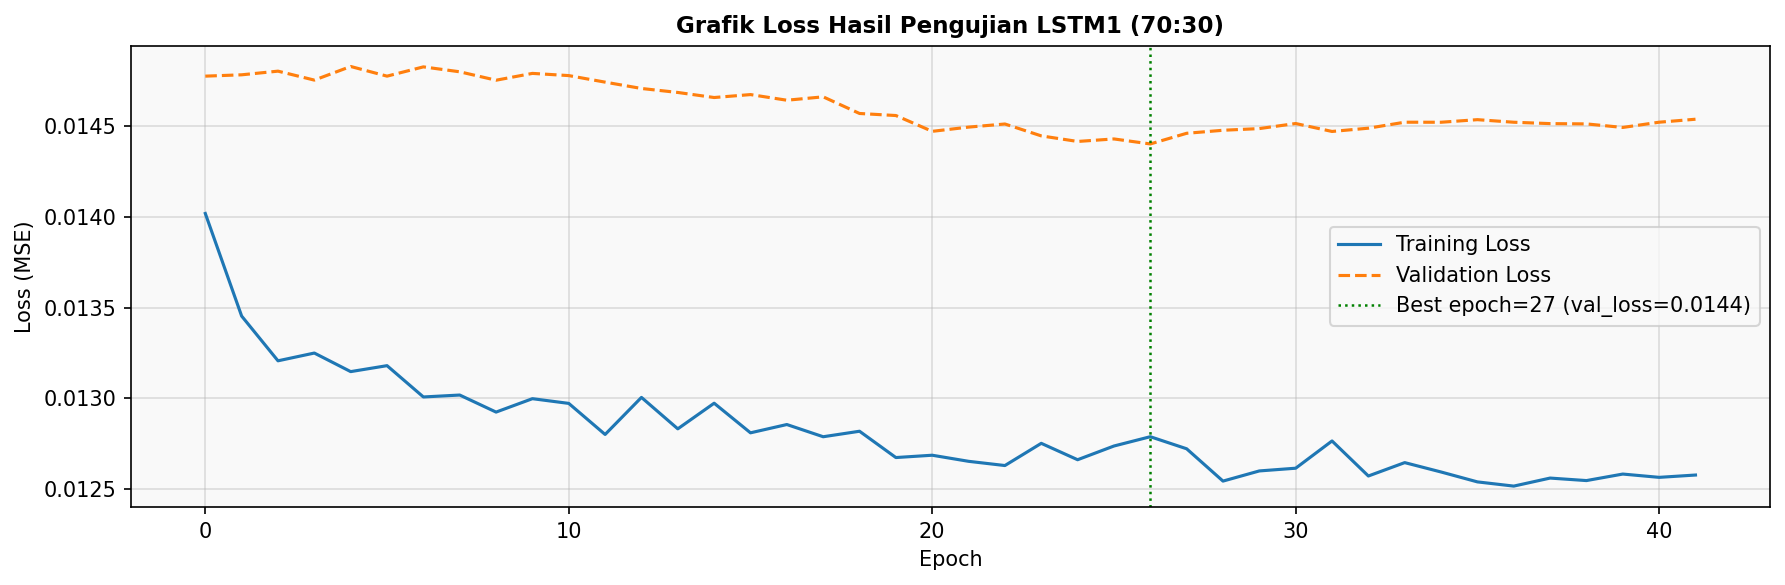

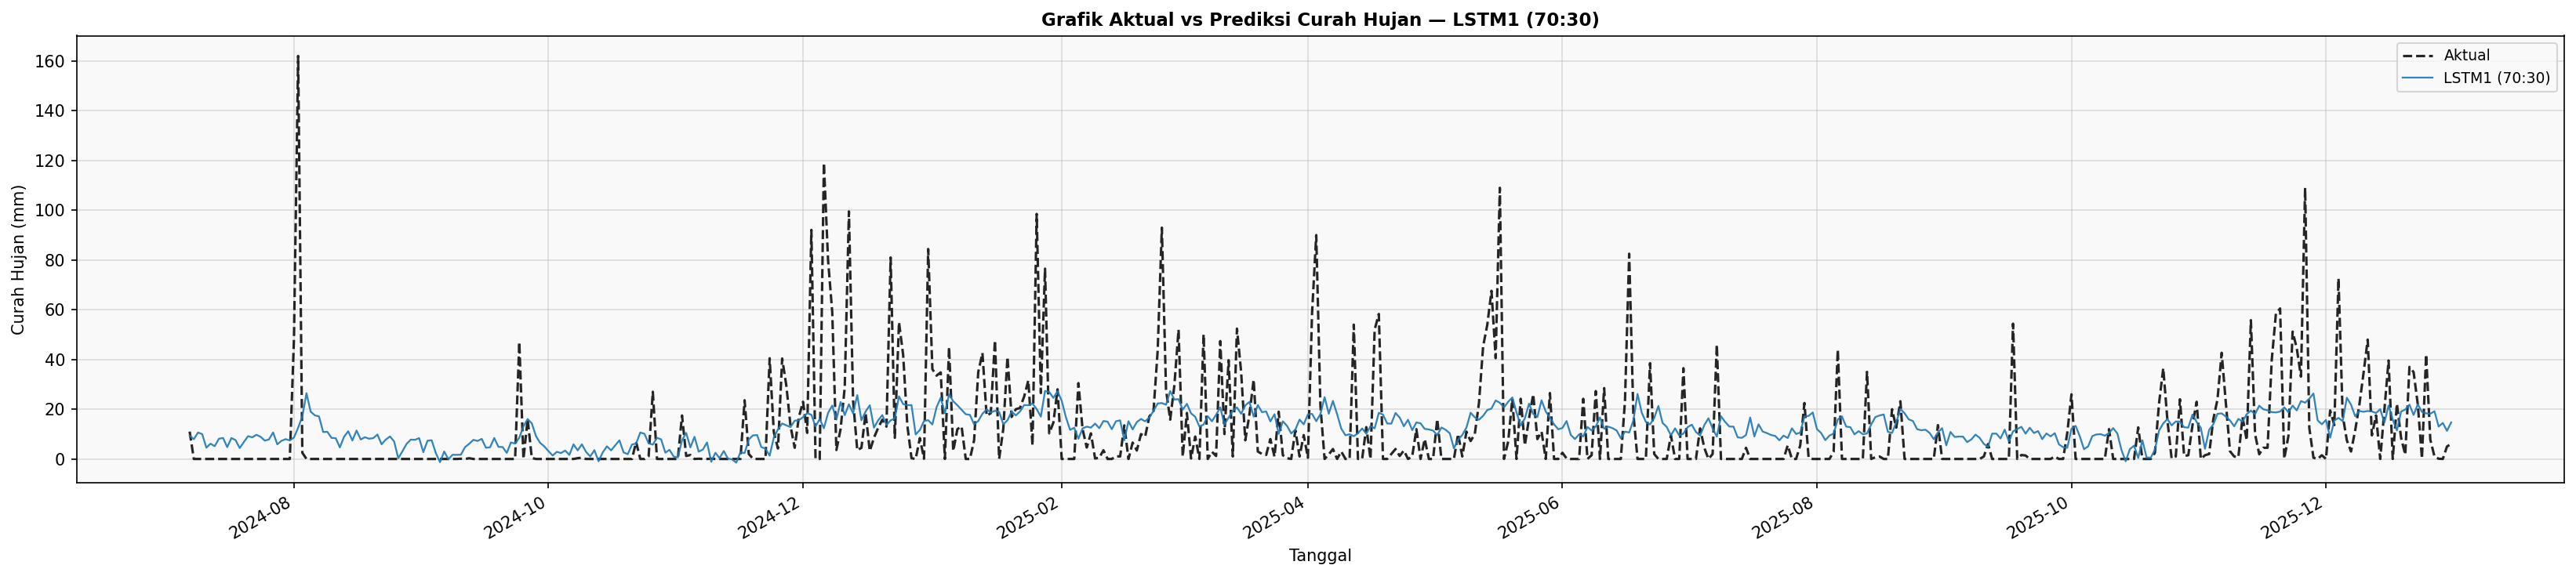


Metrik Evaluasi Skenario LSTM1:
  Metrik   |        Nilai
  ---------+-------------
  RMSE     |      19.2014
  MAE      |      12.9506
  NSE      |       0.1273
  R²       |       0.1273


{'Model': 'LSTM1 (70:30)',
 'RMSE': 19.20142470218751,
 'MAE': 12.950621474670386,
 'NSE': 0.1273355259959904,
 'R2': 0.1273355259959904}

In [14]:
plot_loss(hist_bl70, 'Grafik Loss Hasil Pengujian LSTM1 (70:30)', 'lstm1_loss.png')
plot_pred(d_te70, actual_70mm, {'LSTM1 (70:30)': pred_bl70},
          'Grafik Aktual vs Prediksi Curah Hujan — LSTM1 (70:30)', 'lstm1_pred.png')
print('\nMetrik Evaluasi Skenario LSTM1:')
evaluate(actual_70mm, pred_bl70, 'LSTM1 (70:30)')

### Skenario LSTM2  80:20

In [15]:
print('=' * 55)
print('  SKENARIO LSTM2 — Pembagian Data 80:20')
print('=' * 55)

actual_80mm = inv_ch(y_te80)

# ── CHECKPOINT ──
ckpt_bl80 = ckpt_load('LSTM2_80')
if ckpt_bl80:
    print('  [CHECKPOINT] LSTM2 (80:20) dimuat dari checkpoint, training dilewati.')
    hist_bl80  = ckpt_bl80['history']
    pred_bl80  = ckpt_bl80['pred']
    m_bl80     = ckpt_bl80['metrics']
    timing['LSTM2 (80:20)'] = ckpt_bl80['time']
else:
    tf.keras.backend.clear_session()
    model_bl2 = build_model(128, 128, 0.001)
    t0 = time.time()
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    _hist = model_bl2.fit(
        X_tr80, y_tr80, epochs=100, batch_size=16,
        validation_data=(X_val80, y_val80), verbose=1,
        callbacks=[es]
    )
    timing['LSTM2 (80:20)'] = time.time() - t0
    hist_bl80 = {k: list(v) for k, v in _hist.history.items()}
    pred_bl80 = inv_ch(model_bl2.predict(X_te80, verbose=0).ravel())
    m_bl80    = evaluate(actual_80mm, pred_bl80, 'LSTM2 (80:20)')
    ckpt_save('LSTM2_80', {
        'history': hist_bl80, 'pred': pred_bl80,
        'metrics': m_bl80,    'time': timing['LSTM2 (80:20)']
    })

results_all.append(m_bl80)
best_ep = int(np.argmin(hist_bl80['val_loss'])) + 1
best_vl = min(hist_bl80['val_loss'])
print(f'\nNilai validation loss terkecil pada epoch ke-{best_ep}: {best_vl:.4f}')
print(f'Data latih   : {X_tr80.shape[0]} sampel')
print(f'Data validasi: {X_val80.shape[0]} sampel')
print(f'Data uji     : {X_te80.shape[0]} sampel')

  SKENARIO LSTM2 — Pembagian Data 80:20
  [CHECKPOINT] LSTM2 (80:20) dimuat dari checkpoint, training dilewati.

Nilai validation loss terkecil pada epoch ke-28: 0.0156
Data latih   : 1156 sampel
Data validasi: 290 sampel
Data uji     : 362 sampel


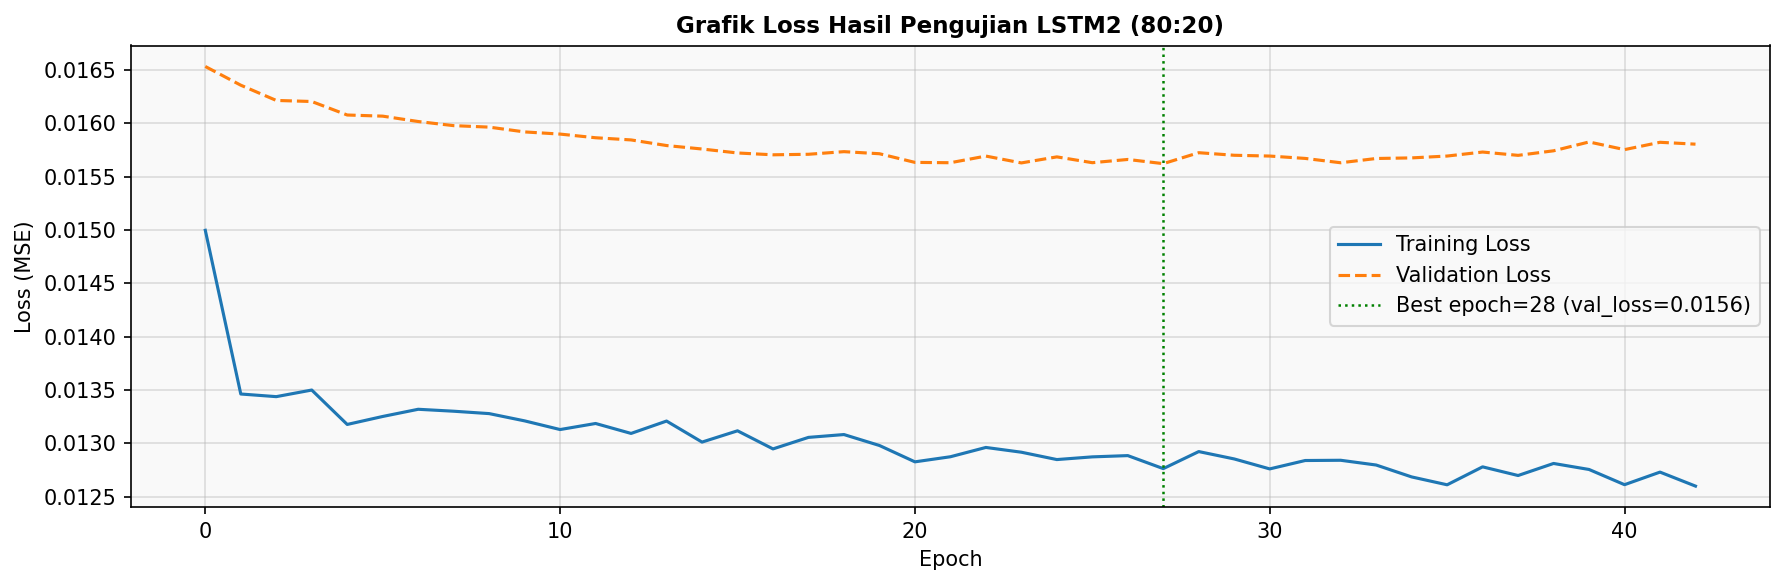

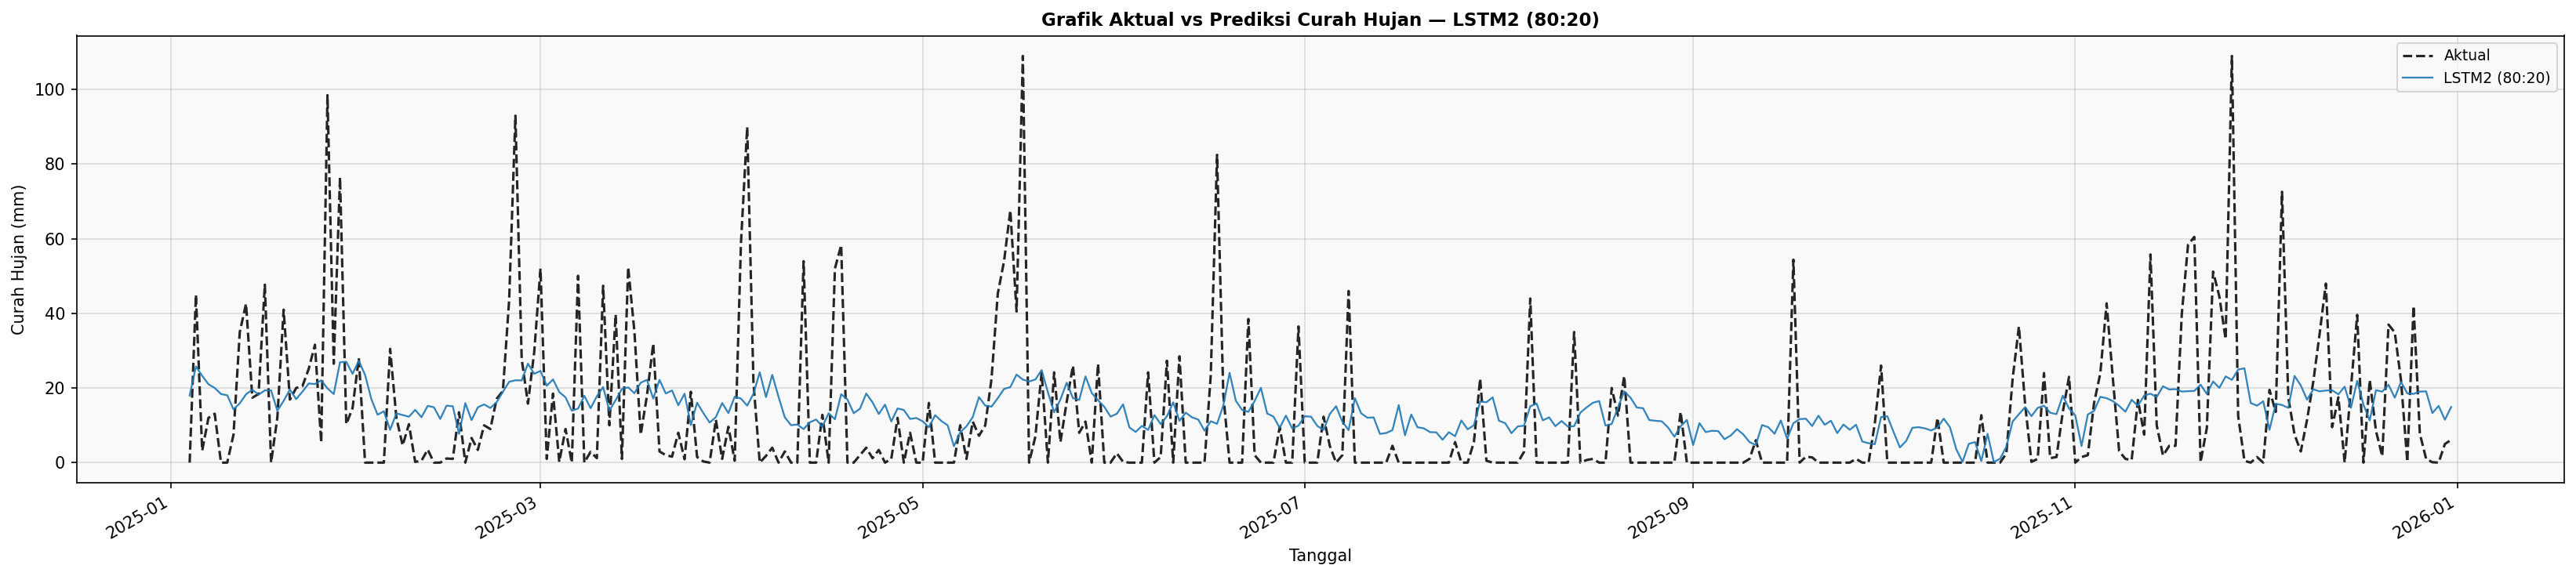


Metrik Evaluasi Skenario LSTM2:
  Metrik   |        Nilai
  ---------+-------------
  RMSE     |      18.2754
  MAE      |      13.7397
  NSE      |       0.1092
  R²       |       0.1092

Kesimpulan: split terbaik (RMSE terkecil) → 80:20
Split ini akan digunakan untuk semua skenario LSTM-PSO.


In [16]:
plot_loss(hist_bl80, 'Grafik Loss Hasil Pengujian LSTM2 (80:20)', 'lstm2_loss.png')
plot_pred(d_te80, actual_80mm, {'LSTM2 (80:20)': pred_bl80},
          'Grafik Aktual vs Prediksi Curah Hujan — LSTM2 (80:20)', 'lstm2_pred.png')
print('\nMetrik Evaluasi Skenario LSTM2:')
evaluate(actual_80mm, pred_bl80, 'LSTM2 (80:20)')

split_terbaik = '80:20' if m_bl80['RMSE'] <= m_bl70['RMSE'] else '70:30'
print(f'\nKesimpulan: split terbaik (RMSE terkecil) → {split_terbaik}')
print('Split ini akan digunakan untuk semua skenario LSTM-PSO.')


## Skenario 2  LSTM-PSO (Pencarian Parameter Bertahap)

Semua skenario PSO menggunakan split **80:20**.

| Tahap | Parameter diuji | Parameter tetap |
|---|---|---|
| PSO1–PSO2 | w: {0.7, 0.8, 0.9} | swarm=10, iter=10, c1=1.5, c2=2.0 |
| PSO3–PSO5 | (c1,c2): {(1.5,1.5), (1.5,2.0), (2.0,2.0)} | w=terbaik, swarm=10, iter=10 |
| PSO6–PSO7 | swarm: {10, 20} | w=terbaik, c=terbaik, iter=10 |
| PSO8–PSO9 | iter: {10, 20} | w=terbaik, c=terbaik, swarm=terbaik |


### Skenario LSTM-PSO1 w=0.7

In [17]:
### Skenario LSTM-PSO1  w=0.7
_W1, _SWARM, _C1, _C2, _ITER = 0.7, 10, 1.5, 2.0, 10

ckpt_pso1 = ckpt_load('PSO1')
if ckpt_pso1:
    print('  [CHECKPOINT] PSO1 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso1 = ckpt_pso1['gbest']; gfit_pso1 = ckpt_pso1['gfit']
    conv_pso1  = ckpt_pso1['conv'];  timing['LSTM-PSO1'] = ckpt_pso1['time']
    if not any(r['Skenario']=='LSTM-PSO1' for r in pso_log):
        pso_log.append(ckpt_pso1['log'])
else:
    print(f'Parameter: w={_W1}, partikel={_SWARM}, c1={_C1}, c2={_C2}, iterasi={_ITER}')
    t0 = time.time()
    gbest_pso1, gfit_pso1, conv_pso1 = run_pso(
        _SWARM, _ITER, _W1, _C1, _C2,
        X_tr80, y_tr80, X_val80, y_val80, label='LSTM-PSO1'
    )
    timing['LSTM-PSO1'] = time.time() - t0
    log1 = {'Skenario':'LSTM-PSO1','w':_W1,'c1':_C1,'c2':_C2,
            'swarm':_SWARM,'iter':_ITER,'fitness':gfit_pso1,'gbest':gbest_pso1}
    pso_log.append(log1)
    ckpt_save('PSO1', {'gbest':gbest_pso1,'gfit':gfit_pso1,
                       'conv':conv_pso1,'time':timing['LSTM-PSO1'],'log':log1})

  [CHECKPOINT] PSO1 dimuat dari checkpoint, PSO dilewati.


In [18]:
ckpt_m1 = ckpt_load('m_PSO1')
if ckpt_m1:
    print('  [CHECKPOINT] Model PSO1 dimuat dari checkpoint, training dilewati.')
    m_pso1 = ckpt_m1['metrics']; pred_pso1 = ckpt_m1['pred']
else:
    m_pso1, pred_pso1, _ = train_best_model(
        gbest_pso1, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO1', 'pso1'
    )
    ckpt_save('m_PSO1', {'metrics': m_pso1, 'pred': pred_pso1})
results_all.append(m_pso1)

  [CHECKPOINT] Model PSO1 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO2  w=0.8

In [19]:
_W2, _SWARM, _C1, _C2, _ITER = 0.8, 10, 1.5, 2.0, 10

# ── CHECKPOINT ──
ckpt_pso2 = ckpt_load('PSO2')
if ckpt_pso2:
    print('  [CHECKPOINT] PSO2 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso2 = ckpt_pso2['gbest']; gfit_pso2 = ckpt_pso2['gfit']
    conv_pso2  = ckpt_pso2['conv'];  timing['LSTM-PSO2'] = ckpt_pso2['time']
    if not any(r['Skenario']=='LSTM-PSO2' for r in pso_log):
        pso_log.append(ckpt_pso2['log'])
else:
    print(f'Parameter: w={_W2}, partikel={_SWARM}, c1={_C1}, c2={_C2}, iterasi={_ITER}')
    t0 = time.time()
    gbest_pso2, gfit_pso2, conv_pso2 = run_pso(
        _SWARM, _ITER, _W2, _C1, _C2,
        X_tr80, y_tr80, X_val80, y_val80, label='LSTM-PSO2'
    )
    timing['LSTM-PSO2'] = time.time() - t0
    log2 = {'Skenario':'LSTM-PSO2','w':_W2,'c1':_C1,'c2':_C2,
            'swarm':_SWARM,'iter':_ITER,'fitness':gfit_pso2,'gbest':gbest_pso2}
    pso_log.append(log2)
    ckpt_save('PSO2', {'gbest':gbest_pso2,'gfit':gfit_pso2,
                       'conv':conv_pso2,'time':timing['LSTM-PSO2'],'log':log2})

  [CHECKPOINT] PSO2 dimuat dari checkpoint, PSO dilewati.


In [20]:
ckpt_m2 = ckpt_load('m_PSO2')
if ckpt_m2:
    print('  [CHECKPOINT] Model PSO2 dimuat dari checkpoint, training dilewati.')
    m_pso2 = ckpt_m2['metrics']; pred_pso2 = ckpt_m2['pred']
else:
    m_pso2, pred_pso2, _ = train_best_model(
        gbest_pso2, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO2', 'pso2'
    )
    ckpt_save('m_PSO2', {'metrics': m_pso2, 'pred': pred_pso2})
results_all.append(m_pso2)

  [CHECKPOINT] Model PSO2 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO2  w=0.9

In [21]:
_W3 = 0.9

# ── CHECKPOINT ──
ckpt_pso3 = ckpt_load('PSO3')
if ckpt_pso3:
    print('  [CHECKPOINT] PSO3 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso3 = ckpt_pso3['gbest']; gfit_pso3 = ckpt_pso3['gfit']
    conv_pso3  = ckpt_pso3['conv'];  timing['LSTM-PSO3'] = ckpt_pso3['time']
    if not any(r['Skenario']=='LSTM-PSO3' for r in pso_log):
        pso_log.append(ckpt_pso3['log'])
else:
    t0 = time.time()
    gbest_pso3, gfit_pso3, conv_pso3 = run_pso(
        10, 10, _W3, 1.5, 2.0,
        X_tr80, y_tr80, X_val80, y_val80, label='LSTM-PSO3'
    )
    timing['LSTM-PSO3'] = time.time() - t0
    log3 = {'Skenario':'LSTM-PSO3','w':_W3,'c1':1.5,'c2':2.0,
            'swarm':10,'iter':10,'fitness':gfit_pso3,'gbest':gbest_pso3}
    pso_log.append(log3)
    ckpt_save('PSO3', {'gbest':gbest_pso3,'gfit':gfit_pso3,
                       'conv':conv_pso3,'time':timing['LSTM-PSO3'],'log':log3})

  [CHECKPOINT] PSO3 dimuat dari checkpoint, PSO dilewati.


In [22]:
ckpt_m3 = ckpt_load('m_PSO3')
if ckpt_m3:
    print('  [CHECKPOINT] Model PSO3 dimuat dari checkpoint, training dilewati.')
    m_pso3 = ckpt_m3['metrics']; pred_pso3 = ckpt_m3['pred']
else:
    m_pso3, pred_pso3, _ = train_best_model(
        gbest_pso3, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO3', 'pso3'
    )
    ckpt_save('m_PSO3', {'metrics': m_pso3, 'pred': pred_pso3})
results_all.append(m_pso3)

BEST_W = 0.7 if gfit_pso1 <= gfit_pso2 and gfit_pso1 <= gfit_pso3 else (0.8 if gfit_pso2 <= gfit_pso3 else 0.9)
print(f'\nKesimpulan Tahap 1:')
print(f'  LSTM-PSO1 (w=0.7) → fitness = {gfit_pso1:.5f}')
print(f'  LSTM-PSO2 (w=0.8) → fitness = {gfit_pso2:.5f}')
print(f'  LSTM-PSO3 (w=0.9) → fitness = {gfit_pso3:.5f}')
print(f'  >> w terbaik: {BEST_W}')

  [CHECKPOINT] Model PSO3 dimuat dari checkpoint, training dilewati.

Kesimpulan Tahap 1:
  LSTM-PSO1 (w=0.7) → fitness = 0.01529
  LSTM-PSO2 (w=0.8) → fitness = 0.01522
  LSTM-PSO3 (w=0.9) → fitness = 0.01521
  >> w terbaik: 0.9


### Skenario LSTM-PSO4  c1=1.5, c2=1.5


In [23]:
# ── CHECKPOINT ──
ckpt_pso4 = ckpt_load('PSO4')
if ckpt_pso4:
    print('  [CHECKPOINT] PSO4 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso4 = ckpt_pso4['gbest']; gfit_pso4 = ckpt_pso4['gfit']
    conv_pso4  = ckpt_pso4['conv'];  timing['LSTM-PSO4'] = ckpt_pso4['time']
    if not any(r['Skenario']=='LSTM-PSO4' for r in pso_log):
        pso_log.append(ckpt_pso4['log'])
else:
    t0 = time.time()
    gbest_pso4, gfit_pso4, conv_pso4 = run_pso(
        10, 10, BEST_W, 1.5, 1.5,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO4 (c1=1.5, c2=1.5, w={BEST_W})'
    )
    timing['LSTM-PSO4'] = time.time() - t0
    log4 = {'Skenario':'LSTM-PSO4','w':BEST_W,'c1':1.5,'c2':1.5,
            'swarm':10,'iter':10,'fitness':gfit_pso4,'gbest':gbest_pso4}
    pso_log.append(log4)
    ckpt_save('PSO4', {'gbest':gbest_pso4,'gfit':gfit_pso4,
                       'conv':conv_pso4,'time':timing['LSTM-PSO4'],'log':log4})


  [CHECKPOINT] PSO4 dimuat dari checkpoint, PSO dilewati.


In [24]:
ckpt_m4 = ckpt_load('m_PSO4')
if ckpt_m4:
    print('  [CHECKPOINT] Model PSO4 dimuat dari checkpoint, training dilewati.')
    m_pso4 = ckpt_m4['metrics']; pred_pso4 = ckpt_m4['pred']
else:
    m_pso4, pred_pso4, _ = train_best_model(
        gbest_pso4, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO4', 'pso4'
    )
    ckpt_save('m_PSO4', {'metrics': m_pso4, 'pred': pred_pso4})
results_all.append(m_pso4)


  [CHECKPOINT] Model PSO4 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO5  c1=1.5, c2=2.0


In [25]:
# ── CHECKPOINT ──
ckpt_pso5 = ckpt_load('PSO5')
if ckpt_pso5:
    print('  [CHECKPOINT] PSO5 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso5 = ckpt_pso5['gbest']; gfit_pso5 = ckpt_pso5['gfit']
    conv_pso5  = ckpt_pso5['conv'];  timing['LSTM-PSO5'] = ckpt_pso5['time']
    if not any(r['Skenario']=='LSTM-PSO5' for r in pso_log):
        pso_log.append(ckpt_pso5['log'])
else:
    t0 = time.time()
    gbest_pso5, gfit_pso5, conv_pso5 = run_pso(
        10, 10, BEST_W, 1.5, 2.0,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO5 (c1=1.5, c2=2.0, w={BEST_W})'
    )
    timing['LSTM-PSO5'] = time.time() - t0
    log5 = {'Skenario':'LSTM-PSO5','w':BEST_W,'c1':1.5,'c2':2.0,
            'swarm':10,'iter':10,'fitness':gfit_pso5,'gbest':gbest_pso5}
    pso_log.append(log5)
    ckpt_save('PSO5', {'gbest':gbest_pso5,'gfit':gfit_pso5,
                       'conv':conv_pso5,'time':timing['LSTM-PSO5'],'log':log5})


  [CHECKPOINT] PSO5 dimuat dari checkpoint, PSO dilewati.


In [26]:
ckpt_m5 = ckpt_load('m_PSO5')
if ckpt_m5:
    print('  [CHECKPOINT] Model PSO5 dimuat dari checkpoint, training dilewati.')
    m_pso5 = ckpt_m5['metrics']; pred_pso5 = ckpt_m5['pred']
else:
    m_pso5, pred_pso5, _ = train_best_model(
        gbest_pso5, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO5', 'pso5'
    )
    ckpt_save('m_PSO5', {'metrics': m_pso5, 'pred': pred_pso5})
results_all.append(m_pso5)


  [CHECKPOINT] Model PSO5 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO6  c1=2.0, c2=2.0


In [27]:
# ── CHECKPOINT ──
ckpt_pso6 = ckpt_load('PSO6')
if ckpt_pso6:
    print('  [CHECKPOINT] PSO6 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso6 = ckpt_pso6['gbest']; gfit_pso6 = ckpt_pso6['gfit']
    conv_pso6  = ckpt_pso6['conv'];  timing['LSTM-PSO6'] = ckpt_pso6['time']
    if not any(r['Skenario']=='LSTM-PSO6' for r in pso_log):
        pso_log.append(ckpt_pso6['log'])
else:
    t0 = time.time()
    gbest_pso6, gfit_pso6, conv_pso6 = run_pso(
        10, 10, BEST_W, 2.0, 2.0,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO6 (c1=2.0, c2=2.0, w={BEST_W})'
    )
    timing['LSTM-PSO6'] = time.time() - t0
    log6 = {'Skenario':'LSTM-PSO6','w':BEST_W,'c1':2.0,'c2':2.0,
            'swarm':10,'iter':10,'fitness':gfit_pso6,'gbest':gbest_pso6}
    pso_log.append(log6)
    ckpt_save('PSO6', {'gbest':gbest_pso6,'gfit':gfit_pso6,
                       'conv':conv_pso6,'time':timing['LSTM-PSO6'],'log':log6})


  [CHECKPOINT] PSO6 dimuat dari checkpoint, PSO dilewati.


In [28]:
ckpt_m6 = ckpt_load('m_PSO6')
if ckpt_m6:
    print('  [CHECKPOINT] Model PSO6 dimuat dari checkpoint, training dilewati.')
    m_pso6 = ckpt_m6['metrics']; pred_pso6 = ckpt_m6['pred']
else:
    m_pso6, pred_pso6, _ = train_best_model(
        gbest_pso6, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO6', 'pso6'
    )
    ckpt_save('m_PSO6', {'metrics': m_pso6, 'pred': pred_pso6})
results_all.append(m_pso6)

best_c_fit = min(gfit_pso4, gfit_pso5, gfit_pso6)
if best_c_fit == gfit_pso4:
    BEST_C1, BEST_C2 = 1.5, 1.5
elif best_c_fit == gfit_pso5:
    BEST_C1, BEST_C2 = 1.5, 2.0
elif best_c_fit == gfit_pso6:
    BEST_C1, BEST_C2 = 2.0, 2.0
else:
    BEST_C1, BEST_C2 = 2.0, 2.0
print(f'\nKesimpulan Tahap 2:')
print(f'  LSTM-PSO4 (c1=1.5, c2=1.5) → fitness = {gfit_pso4:.5f}')
print(f'  LSTM-PSO5 (c1=1.5, c2=2.0) → fitness = {gfit_pso5:.5f}')
print(f'  LSTM-PSO6 (c1=2.0, c2=2.0) → fitness = {gfit_pso6:.5f}')
print(f'  >> c1={BEST_C1}, c2={BEST_C2} (terbaik)')


  [CHECKPOINT] Model PSO6 dimuat dari checkpoint, training dilewati.

Kesimpulan Tahap 2:
  LSTM-PSO4 (c1=1.5, c2=1.5) → fitness = 0.01533
  LSTM-PSO5 (c1=1.5, c2=2.0) → fitness = 0.01533
  LSTM-PSO6 (c1=2.0, c2=2.0) → fitness = 0.01530
  >> c1=2.0, c2=2.0 (terbaik)


### Skenario LSTM-PSO7  Swarm Size = 10


In [29]:
# ── CHECKPOINT ──
ckpt_pso7 = ckpt_load('PSO7')
if ckpt_pso7:
    print('  [CHECKPOINT] PSO7 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso7 = ckpt_pso7['gbest']; gfit_pso7 = ckpt_pso7['gfit']
    conv_pso7  = ckpt_pso7['conv'];  timing['LSTM-PSO7'] = ckpt_pso7['time']
    if not any(r['Skenario']=='LSTM-PSO7' for r in pso_log):
        pso_log.append(ckpt_pso7['log'])
else:
    t0 = time.time()
    gbest_pso7, gfit_pso7, conv_pso7 = run_pso(
        10, 10, BEST_W, BEST_C1, BEST_C2,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO7 (swarm=10, w={BEST_W}, c1={BEST_C1})'
    )
    timing['LSTM-PSO7'] = time.time() - t0
    log7 = {'Skenario':'LSTM-PSO7','w':BEST_W,'c1':BEST_C1,'c2':BEST_C2,
            'swarm':10,'iter':10,'fitness':gfit_pso7,'gbest':gbest_pso7}
    pso_log.append(log7)
    ckpt_save('PSO7', {'gbest':gbest_pso7,'gfit':gfit_pso7,
                       'conv':conv_pso7,'time':timing['LSTM-PSO7'],'log':log7})


  [CHECKPOINT] PSO7 dimuat dari checkpoint, PSO dilewati.


In [30]:
ckpt_m7 = ckpt_load('m_PSO7')
if ckpt_m7:
    print('  [CHECKPOINT] Model PSO7 dimuat dari checkpoint, training dilewati.')
    m_pso7 = ckpt_m7['metrics']; pred_pso7 = ckpt_m7['pred']
else:
    m_pso7, pred_pso7, _ = train_best_model(
        gbest_pso7, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO7', 'pso7'
    )
    ckpt_save('m_PSO7', {'metrics': m_pso7, 'pred': pred_pso7})
results_all.append(m_pso7)


  [CHECKPOINT] Model PSO7 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO8  Swarm Size = 20


In [31]:
# ── CHECKPOINT ──
ckpt_pso8 = ckpt_load('PSO8')
if ckpt_pso8:
    print('  [CHECKPOINT] PSO8 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso8 = ckpt_pso8['gbest']; gfit_pso8 = ckpt_pso8['gfit']
    conv_pso8  = ckpt_pso8['conv'];  timing['LSTM-PSO8'] = ckpt_pso8['time']
    if not any(r['Skenario']=='LSTM-PSO8' for r in pso_log):
        pso_log.append(ckpt_pso8['log'])
else:
    t0 = time.time()
    gbest_pso8, gfit_pso8, conv_pso8 = run_pso(
        20, 10, BEST_W, BEST_C1, BEST_C2,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO8 (swarm=20, w={BEST_W}, c1={BEST_C1})'
    )
    timing['LSTM-PSO8'] = time.time() - t0
    log8 = {'Skenario':'LSTM-PSO8','w':BEST_W,'c1':BEST_C1,'c2':BEST_C2,
            'swarm':20,'iter':10,'fitness':gfit_pso8,'gbest':gbest_pso8}
    pso_log.append(log8)
    ckpt_save('PSO8', {'gbest':gbest_pso8,'gfit':gfit_pso8,
                       'conv':conv_pso8,'time':timing['LSTM-PSO8'],'log':log8})


  [CHECKPOINT] PSO8 dimuat dari checkpoint, PSO dilewati.


In [32]:
ckpt_m8 = ckpt_load('m_PSO8')
if ckpt_m8:
    print('  [CHECKPOINT] Model PSO8 dimuat dari checkpoint, training dilewati.')
    m_pso8 = ckpt_m8['metrics']; pred_pso8 = ckpt_m8['pred']
else:
    m_pso8, pred_pso8, _ = train_best_model(
        gbest_pso8, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO8', 'pso8'
    )
    ckpt_save('m_PSO8', {'metrics': m_pso8, 'pred': pred_pso8})
results_all.append(m_pso8)

BEST_SWARM = 10 if gfit_pso7 <= gfit_pso8 else 20
print(f'\nKesimpulan Tahap 3:')
print(f'  LSTM-PSO7 (swarm=10) → fitness = {gfit_pso7:.5f}')
print(f'  LSTM-PSO8 (swarm=20) → fitness = {gfit_pso8:.5f}')
print(f'  >> swarm_size terbaik: {BEST_SWARM}')


  [CHECKPOINT] Model PSO8 dimuat dari checkpoint, training dilewati.

Kesimpulan Tahap 3:
  LSTM-PSO7 (swarm=10) → fitness = 0.01510
  LSTM-PSO8 (swarm=20) → fitness = 0.01518
  >> swarm_size terbaik: 10


### Skenario LSTM-PSO9  Iterasi = 10


In [33]:
# ── CHECKPOINT ──
ckpt_pso9 = ckpt_load('PSO9')
if ckpt_pso9:
    print('  [CHECKPOINT] PSO9 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso9 = ckpt_pso9['gbest']; gfit_pso9 = ckpt_pso9['gfit']
    conv_pso9  = ckpt_pso9['conv'];  timing['LSTM-PSO9'] = ckpt_pso9['time']
    if not any(r['Skenario']=='LSTM-PSO9' for r in pso_log):
        pso_log.append(ckpt_pso9['log'])
else:
    t0 = time.time()
    gbest_pso9, gfit_pso9, conv_pso9 = run_pso(
        BEST_SWARM, 10, BEST_W, BEST_C1, BEST_C2,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO9 (iter=10, swarm={BEST_SWARM}, w={BEST_W})'
    )
    timing['LSTM-PSO9'] = time.time() - t0
    log9 = {'Skenario':'LSTM-PSO9','w':BEST_W,'c1':BEST_C1,'c2':BEST_C2,
            'swarm':BEST_SWARM,'iter':10,'fitness':gfit_pso9,'gbest':gbest_pso9}
    pso_log.append(log9)
    ckpt_save('PSO9', {'gbest':gbest_pso9,'gfit':gfit_pso9,
                       'conv':conv_pso9,'time':timing['LSTM-PSO9'],'log':log9})


  [CHECKPOINT] PSO9 dimuat dari checkpoint, PSO dilewati.


In [34]:
ckpt_m9 = ckpt_load('m_PSO9')
if ckpt_m9:
    print('  [CHECKPOINT] Model PSO9 dimuat dari checkpoint, training dilewati.')
    m_pso9 = ckpt_m9['metrics']; pred_pso9 = ckpt_m9['pred']
else:
    m_pso9, pred_pso9, _ = train_best_model(
        gbest_pso9, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO9', 'pso9'
    )
    ckpt_save('m_PSO9', {'metrics': m_pso9, 'pred': pred_pso9})
results_all.append(m_pso9)


  [CHECKPOINT] Model PSO9 dimuat dari checkpoint, training dilewati.


### Skenario LSTM-PSO10  Iterasi = 20


In [35]:
# ── CHECKPOINT ──
ckpt_pso10 = ckpt_load('PSO10')
if ckpt_pso10:
    print('  [CHECKPOINT] PSO10 dimuat dari checkpoint, PSO dilewati.')
    gbest_pso10 = ckpt_pso10['gbest']; gfit_pso10 = ckpt_pso10['gfit']
    conv_pso10  = ckpt_pso10['conv'];  timing['LSTM-PSO10'] = ckpt_pso10['time']
    if not any(r['Skenario']=='LSTM-PSO10' for r in pso_log):
        pso_log.append(ckpt_pso10['log'])
else:
    t0 = time.time()
    gbest_pso10, gfit_pso10, conv_pso10 = run_pso(
        BEST_SWARM, 20, BEST_W, BEST_C1, BEST_C2,
        X_tr80, y_tr80, X_val80, y_val80,
        label=f'LSTM-PSO10 (iter=20, swarm={BEST_SWARM}, w={BEST_W})'
    )
    timing['LSTM-PSO10'] = time.time() - t0
    log10 = {'Skenario':'LSTM-PSO10','w':BEST_W,'c1':BEST_C1,'c2':BEST_C2,
            'swarm':BEST_SWARM,'iter':20,'fitness':gfit_pso10,'gbest':gbest_pso10}
    pso_log.append(log10)
    ckpt_save('PSO10', {'gbest':gbest_pso10,'gfit':gfit_pso10,
                       'conv':conv_pso10,'time':timing['LSTM-PSO10'],'log':log10})


  [CHECKPOINT] PSO10 dimuat dari checkpoint, PSO dilewati.


In [36]:
ckpt_m10 = ckpt_load('m_PSO10')
if ckpt_m10:
    print('  [CHECKPOINT] Model PSO10 dimuat dari checkpoint, training dilewati.')
    m_pso10 = ckpt_m10['metrics']; pred_pso10 = ckpt_m10['pred']
else:
    m_pso10, pred_pso10, _ = train_best_model(
        gbest_pso10, X_tr80, y_tr80, X_val80, y_val80,
        X_te80, y_te80, d_te80, actual_80mm, 'LSTM-PSO10', 'pso10'
    )
    ckpt_save('m_PSO10', {'metrics': m_pso10, 'pred': pred_pso10})
results_all.append(m_pso10)

BEST_ITER = 10 if gfit_pso9 <= gfit_pso10 else 20
print(f'\nKesimpulan Tahap 4:')
print(f'  LSTM-PSO9 (iter=10) → fitness = {gfit_pso9:.5f}')
print(f'  LSTM-PSO10 (iter=20) → fitness = {gfit_pso10:.5f}')
print(f'  >> iterasi terbaik: {BEST_ITER}')


  [CHECKPOINT] Model PSO10 dimuat dari checkpoint, training dilewati.

Kesimpulan Tahap 4:
  LSTM-PSO9 (iter=10) → fitness = 0.01531
  LSTM-PSO10 (iter=20) → fitness = 0.01522
  >> iterasi terbaik: 20


### Ringkasan Semua Skenario LSTM-PSO

In [37]:
df_pso = pd.DataFrame([{
    'Skenario': r['Skenario'],
    'w': r['w'], 'c1': r['c1'], 'c2': r['c2'],
    'Swarm': r['swarm'], 'Iterasi': r['iter'],
    'Fitness (val_loss)': round(r['fitness'], 5),
    'N1': int(r['gbest'][0]), 'N2': int(r['gbest'][1]),
    'LR': round(float(r['gbest'][2]), 6),
    'Batch': int(r['gbest'][3])
} for r in pso_log])
print('Tabel Perbandingan Parameter PSO:')
display(df_pso)

pso_metrics = [m for m in results_all if 'LSTM-PSO' in m['Model']]
best_pso    = min(pso_metrics, key=lambda x: x['RMSE'])
print(f'\nSkenario PSO terbaik: {best_pso["Model"]}  (RMSE={best_pso["RMSE"]:.4f})')
print(f'\nParameter PSO terbaik:')
print(f'  w          : {BEST_W}')
print(f'  c1, c2     : {BEST_C1}, {BEST_C2}')
print(f'  Swarm size : {BEST_SWARM}')
print(f'  Iterasi    : {BEST_ITER}')
df_pso.to_csv(os.path.join(SAVE_DIR, 'pso_skenario_log.csv'), index=False)

Tabel Perbandingan Parameter PSO:


,Skenario,w,c1,c2,Swarm,Iterasi,Fitness (val_loss),N1,N2,LR,Batch
0,LSTM-PSO1,0.7,1.5,2.0,10,10,0.01529,235,128,0.007556,16
1,LSTM-PSO2,0.8,1.5,2.0,10,10,0.01522,118,128,0.009793,16
2,LSTM-PSO3,0.9,1.5,2.0,10,10,0.01521,222,104,0.008952,16
3,LSTM-PSO4,0.9,1.5,1.5,10,10,0.01533,256,124,0.007432,32
4,LSTM-PSO5,0.9,1.5,2.0,10,10,0.01533,198,128,0.008819,16
5,LSTM-PSO6,0.9,2.0,2.0,10,10,0.01530,164,73,0.010000,16
6,LSTM-PSO7,0.9,2.0,2.0,10,10,0.01510,192,103,0.009126,32
7,LSTM-PSO8,0.9,2.0,2.0,20,10,0.01518,146,113,0.010000,32
8,LSTM-PSO9,0.9,2.0,2.0,10,10,0.01531,97,76,0.010000,32
9,LSTM-PSO10,0.9,2.0,2.0,10,20,0.01522,241,124,0.008906,16



Skenario PSO terbaik: LSTM-PSO7  (RMSE=18.0230)

Parameter PSO terbaik:
  w          : 0.9
  c1, c2     : 2.0, 2.0
  Swarm size : 10
  Iterasi    : 20


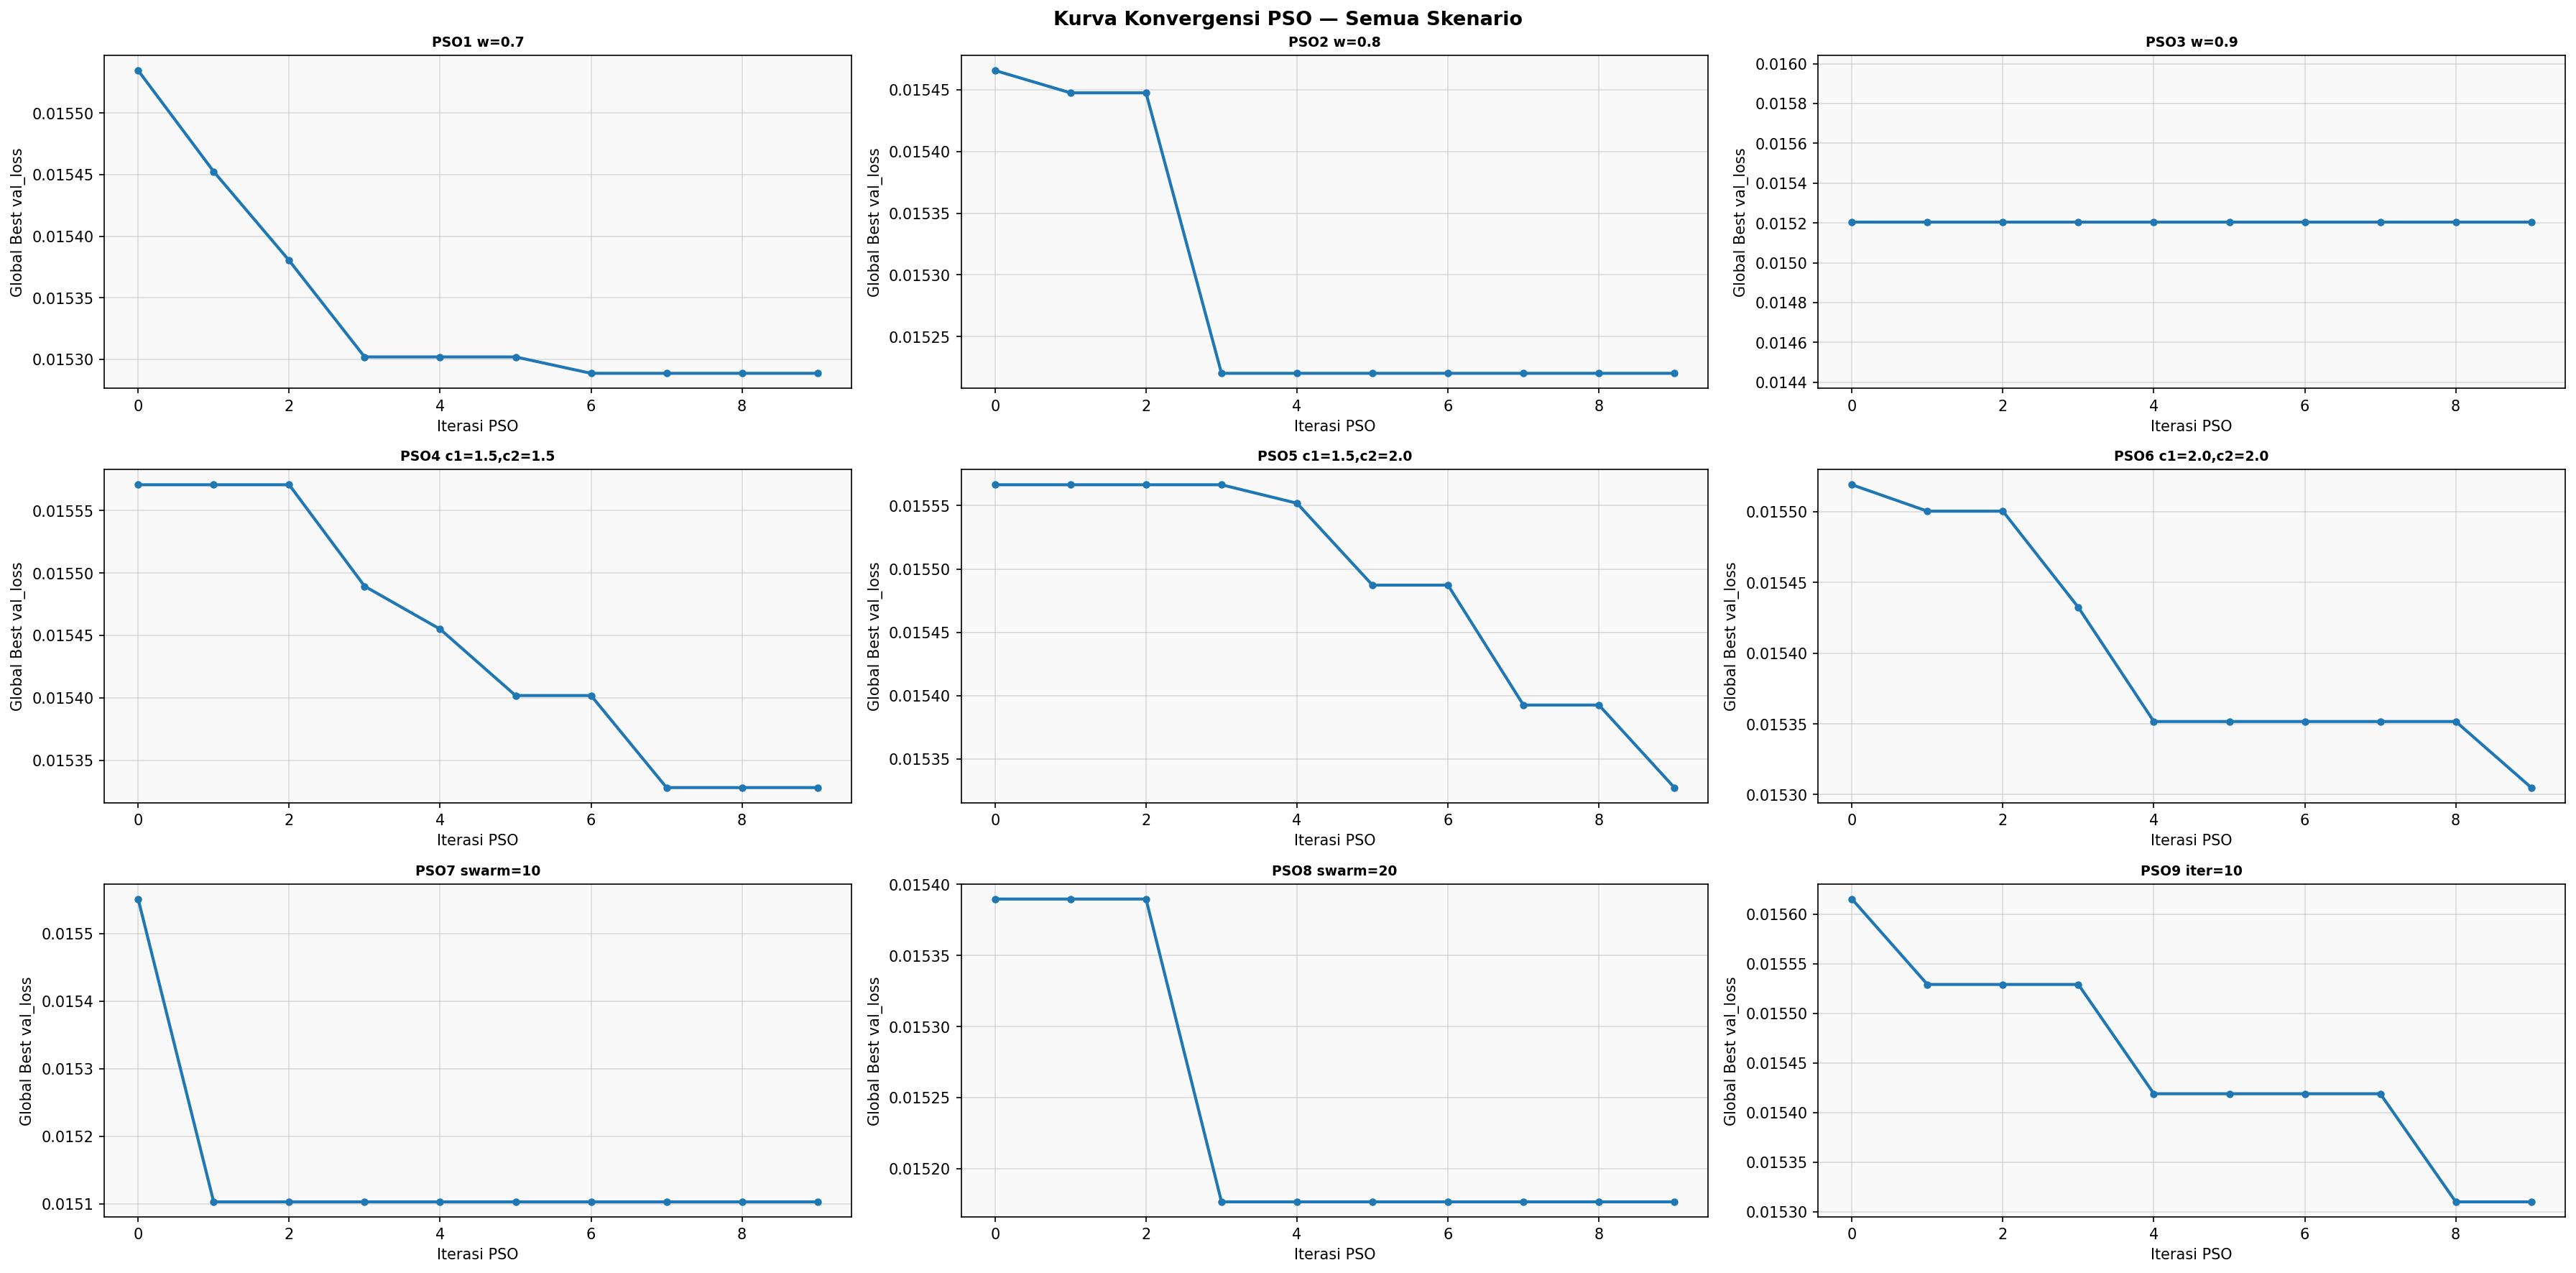

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(24, 12))
fig.suptitle('Kurva Konvergensi PSO — Semua Skenario', fontsize=13, fontweight='bold')

all_conv    = [conv_pso1, conv_pso2, conv_pso3, conv_pso4, conv_pso5,
               conv_pso6, conv_pso7, conv_pso8, conv_pso9, conv_pso10]
labels_conv = ['PSO1 w=0.7', 'PSO2 w=0.8',
               'PSO3 w=0.9', 'PSO4 c1=1.5,c2=1.5', 'PSO5 c1=1.5,c2=2.0',
               f'PSO6 c1=2.0,c2=2.0', f'PSO7 swarm=10',
               f'PSO8 swarm=20',  f'PSO9 iter=10', f'PSO10 iter=20']
for ax, conv, lbl in zip(axes.ravel(), all_conv, labels_conv):
    ax.plot(conv, color='#1f77b4', linewidth=2, marker='o', markersize=4)
    ax.set_title(lbl, fontsize=9, fontweight='bold')
    ax.set_xlabel('Iterasi PSO'); ax.set_ylabel('Global Best val_loss')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pso_semua_konvergensi.png'), bbox_inches='tight')
plt.show()



## Skenario 3  Perbandingan Model

### 3.1 ARIMA

In [39]:
from statsmodels.tsa.stattools import adfuller

series_ch  = df_clean['curah_hujan'].values
result_adf = adfuller(series_ch)
print(f'ADF Statistic : {result_adf[0]:.4f}')
print(f'p-value       : {result_adf[1]:.4f}')
if result_adf[1] < 0.05:
    print('>> Data STASIONER → nilai d = 0'); d_val = 0
else:
    print('>> Data BELUM STASIONER → nilai d = 1'); d_val = 1
print(f'\nModel ARIMA yang digunakan: ARIMA(1, {d_val}, 1)')

ADF Statistic : -6.3018
p-value       : 0.0000
>> Data STASIONER → nilai d = 0

Model ARIMA yang digunakan: ARIMA(1, 0, 1)


  [CHECKPOINT] ARIMA dimuat dari checkpoint.

Metrik Evaluasi ARIMA:
  Metrik   |        Nilai
  ---------+-------------
  RMSE     |      19.2603
  MAE      |      14.7440
  NSE      |       0.0116
  R²       |       0.0116


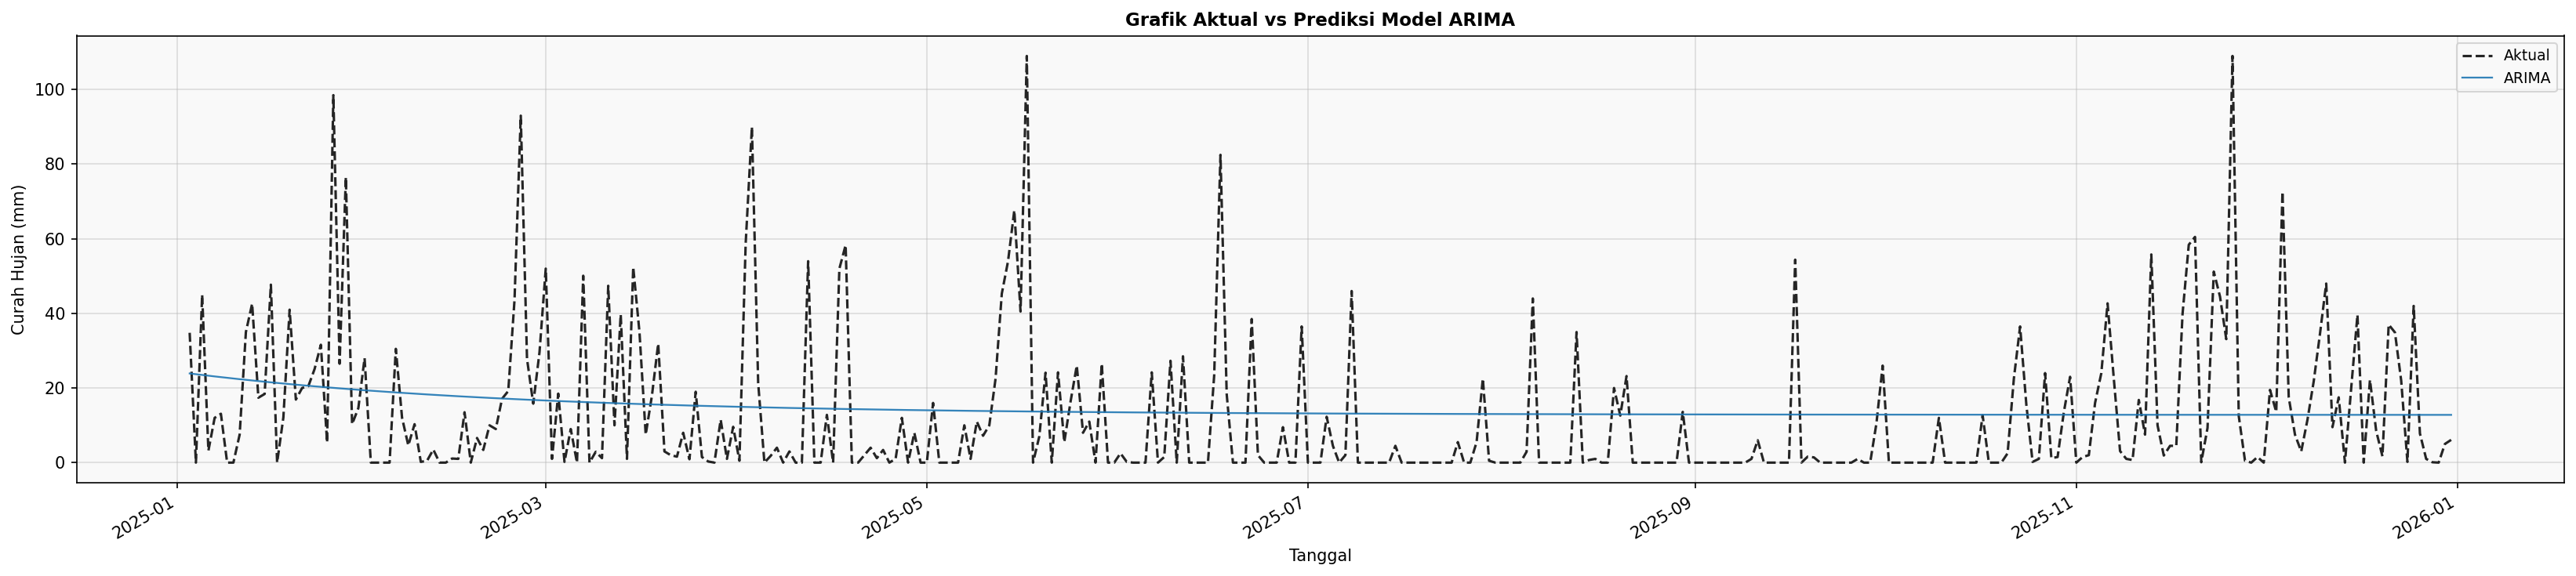

In [40]:
n_total      = len(df_clean)
n_train      = int(n_total * 0.8)
series_train = df_clean['curah_hujan'].iloc[:n_train].values
series_test  = df_clean['curah_hujan'].iloc[n_train:].values
actual_arima = series_test
d_arima      = df_clean.index[n_train:]

# ── CHECKPOINT ──
ckpt_arima = ckpt_load('ARIMA')
if ckpt_arima:
    print('  [CHECKPOINT] ARIMA dimuat dari checkpoint.')
    pred_arima = ckpt_arima['pred']; m_arima = ckpt_arima['metrics']
    timing['ARIMA'] = ckpt_arima['time']
else:
    t0 = time.time()
    arima_fit  = ARIMA(series_train, order=(1, d_val, 1)).fit()
    timing['ARIMA'] = time.time() - t0
    pred_arima = np.maximum(arima_fit.forecast(steps=len(actual_arima)), 0)
    m_arima    = evaluate(actual_arima, pred_arima, 'ARIMA')
    ckpt_save('ARIMA', {'pred': pred_arima, 'metrics': m_arima, 'time': timing['ARIMA']})
results_all.append(m_arima)

print('\nMetrik Evaluasi ARIMA:')
evaluate(actual_arima, pred_arima, 'ARIMA')
plot_pred(d_arima, actual_arima, {'ARIMA': pred_arima},
          'Grafik Aktual vs Prediksi Model ARIMA', 'arima_pred.png')

### 3.2 Triple Exponential Smoothing (TES)

  [CHECKPOINT] TES dimuat dari checkpoint.

Metrik Evaluasi TES:
  Metrik   |        Nilai
  ---------+-------------
  RMSE     |      65.8642
  MAE      |      59.1391
  NSE      |     -10.5586
  R²       |     -10.5586


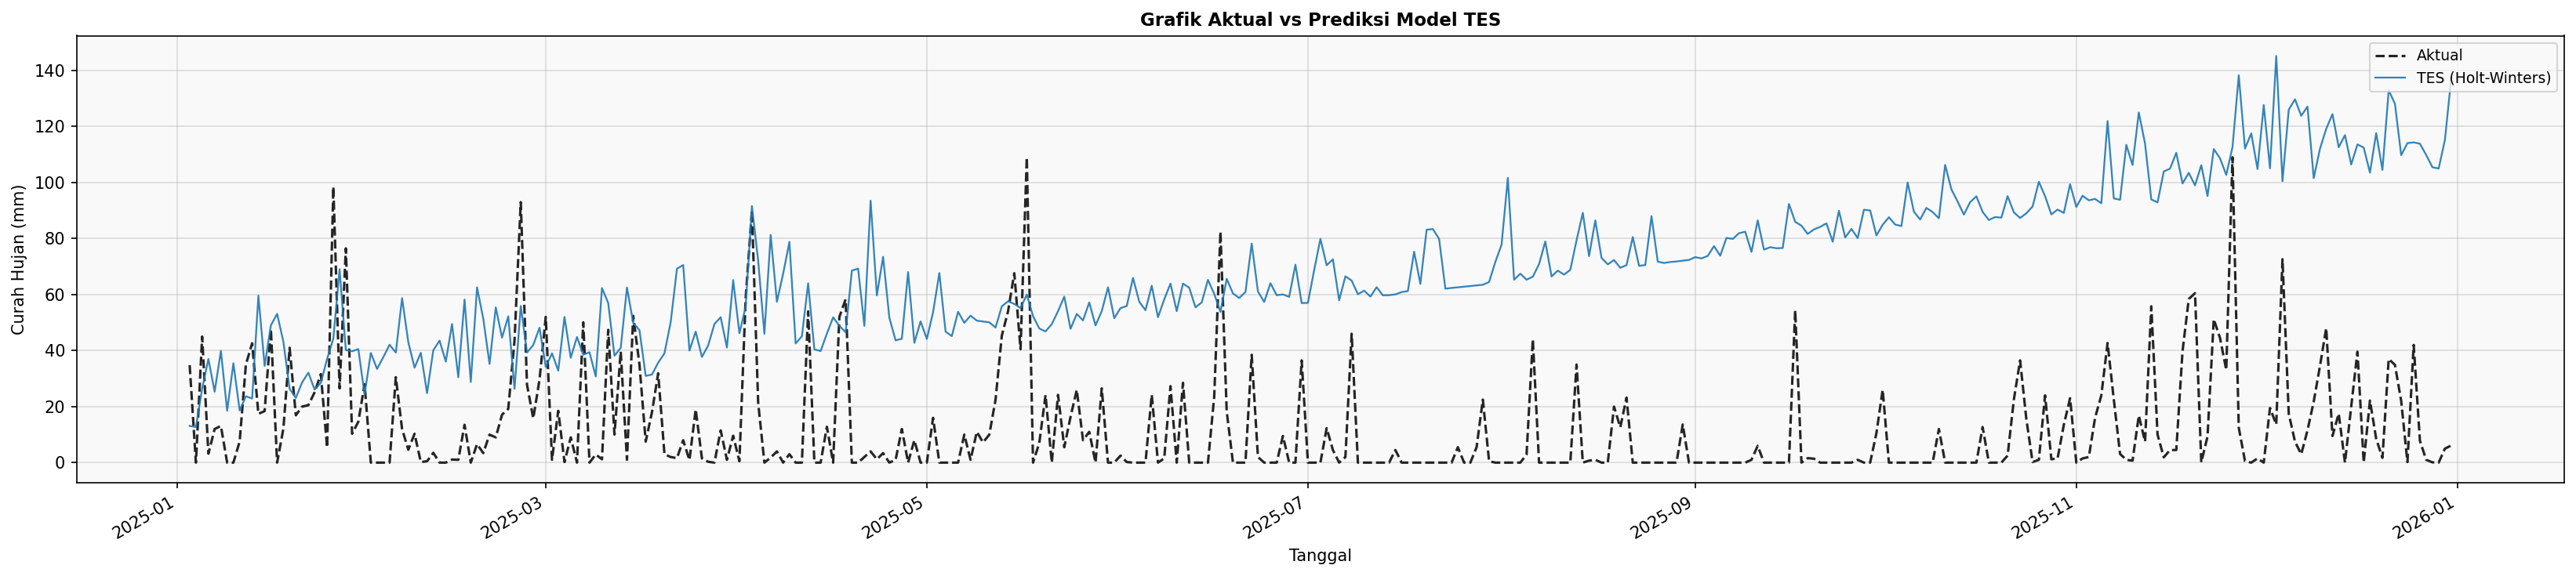

In [41]:
# ── CHECKPOINT ──
ckpt_tes = ckpt_load('TES')
if ckpt_tes:
    print('  [CHECKPOINT] TES dimuat dari checkpoint.')
    pred_tes = ckpt_tes['pred']; m_tes = ckpt_tes['metrics']
    timing['TES'] = ckpt_tes['time']
else:
    t0 = time.time()
    tes_fit = ExponentialSmoothing(
        series_train, trend='add', seasonal='add',
        seasonal_periods=365, initialization_method='estimated'
    ).fit(optimized=True)
    timing['TES'] = time.time() - t0
    pred_tes = np.maximum(tes_fit.forecast(steps=len(actual_arima)), 0)
    m_tes    = evaluate(actual_arima, pred_tes, 'TES (Holt-Winters)')
    ckpt_save('TES', {'pred': pred_tes, 'metrics': m_tes, 'time': timing['TES']})
results_all.append(m_tes)

print('\nMetrik Evaluasi TES:')
evaluate(actual_arima, pred_tes, 'TES (Holt-Winters)')
plot_pred(d_arima, actual_arima, {'TES (Holt-Winters)': pred_tes},
          'Grafik Aktual vs Prediksi Model TES', 'tes_pred.png')

### 3.3 GRU

  [CHECKPOINT] GRU dimuat dari checkpoint, training dilewati.

Nilai validation loss terkecil pada epoch ke-13: 0.0155


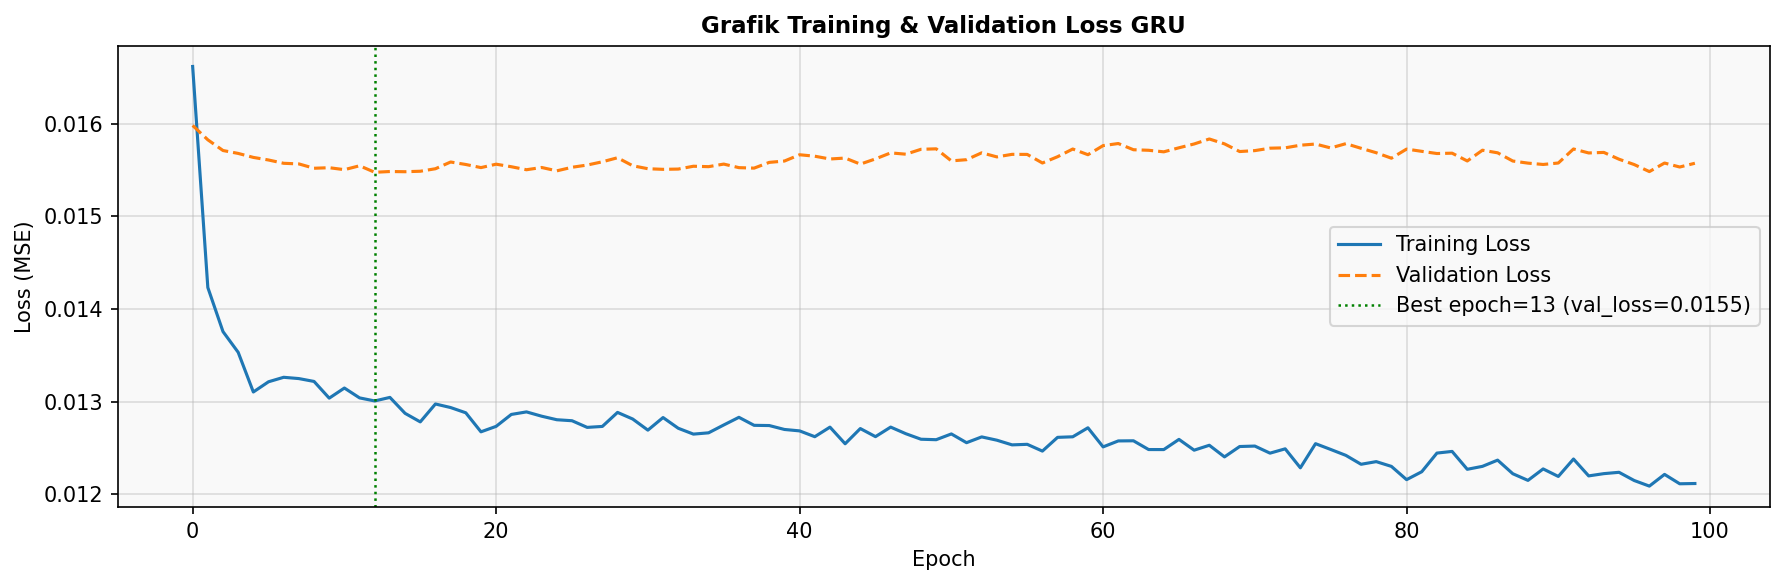

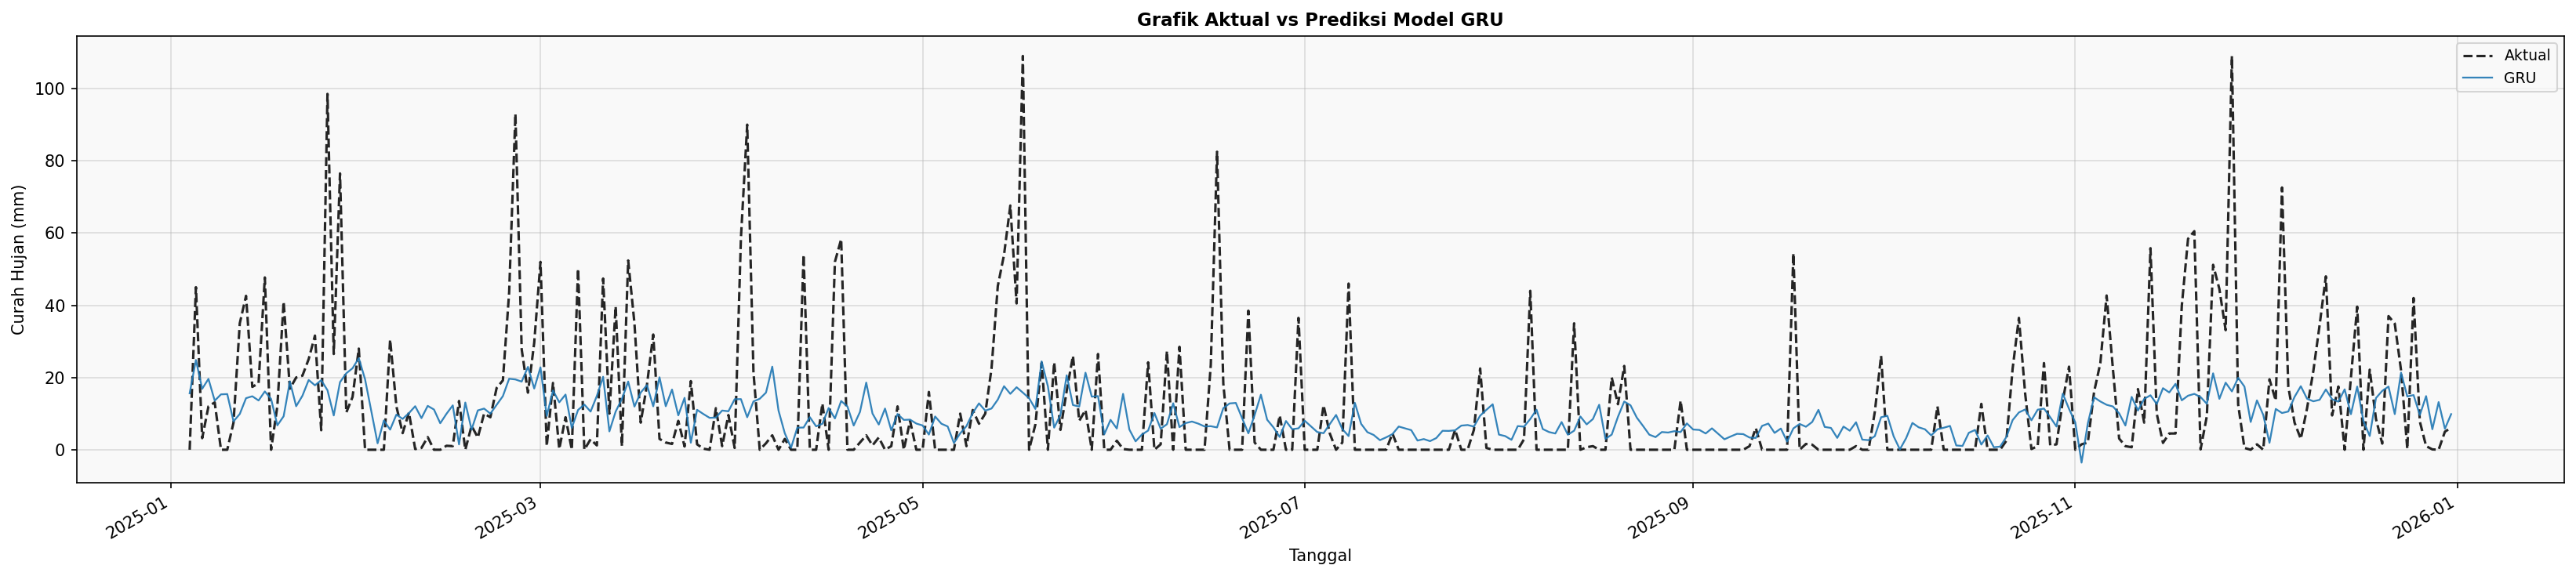


Metrik Evaluasi GRU:
  Metrik   |        Nilai
  ---------+-------------
  RMSE     |      18.2130
  MAE      |      11.9341
  NSE      |       0.1153
  R²       |       0.1153


{'Model': 'GRU',
 'RMSE': 18.213002855018566,
 'MAE': 11.934135737183261,
 'NSE': 0.11525678383642068,
 'R2': 0.11525678383642068}

In [42]:
# ── CHECKPOINT ──
ckpt_gru = ckpt_load('GRU')
if ckpt_gru:
    print('  [CHECKPOINT] GRU dimuat dari checkpoint, training dilewati.')
    hist_gru = ckpt_gru['history']; pred_gru = ckpt_gru['pred']
    m_gru    = ckpt_gru['metrics']; timing['GRU'] = ckpt_gru['time']
else:
    print('>> Melatih GRU (1 layer, 64 neuron, lr=0.001, batch=16)...')
    tf.keras.backend.clear_session()
    model_gru = build_gru(64, 0.001)
    model_gru.summary()
    t0 = time.time()
    _hist = model_gru.fit(
        X_tr80, y_tr80, epochs=100, batch_size=16,
        validation_data=(X_val80, y_val80), verbose=1
    )
    timing['GRU'] = time.time() - t0
    hist_gru = {k: list(v) for k, v in _hist.history.items()}
    pred_gru = inv_ch(model_gru.predict(X_te80, verbose=0).ravel())
    m_gru    = evaluate(actual_80mm, pred_gru, 'GRU')
    ckpt_save('GRU', {'history': hist_gru, 'pred': pred_gru,
                      'metrics': m_gru, 'time': timing['GRU']})
results_all.append(m_gru)

best_ep = int(np.argmin(hist_gru['val_loss'])) + 1
best_vl = min(hist_gru['val_loss'])
print(f'\nNilai validation loss terkecil pada epoch ke-{best_ep}: {best_vl:.4f}')
plot_loss(hist_gru, 'Grafik Training & Validation Loss GRU', 'gru_loss.png')
plot_pred(d_te80, actual_80mm, {'GRU': pred_gru},
          'Grafik Aktual vs Prediksi Model GRU', 'gru_pred.png')
print('\nMetrik Evaluasi GRU:')
evaluate(actual_80mm, pred_gru, 'GRU')


## Hasil Akhir — Perbandingan Semua Model

In [43]:
df_final = (pd.DataFrame(results_all)
              .set_index('Model')
              .sort_values('RMSE'))

print('  PERBANDINGAN SEMUA MODEL — Curah Hujan Kabupaten Pasuruan (mm)')
display(df_final.round(4))
print(f'\n  Model terbaik (RMSE terkecil): {df_final.index[0]}')
print(f'  RMSE : {df_final.iloc[0]["RMSE"]:.4f}')
print(f'  MAE  : {df_final.iloc[0]["MAE"]:.4f}')
print(f'  NSE  : {df_final.iloc[0]["NSE"]:.4f}')
print(f'  R²   : {df_final.iloc[0]["R2"]:.4f}')

  PERBANDINGAN SEMUA MODEL — Curah Hujan Kabupaten Pasuruan (mm)


,RMSE,MAE,NSE,R2
Model,,,,
LSTM-PSO7,18.0230,12.4126,0.1336,0.1336
LSTM-PSO6,18.0841,12.8988,0.1277,0.1277
LSTM-PSO10,18.1173,13.0710,0.1245,0.1245
LSTM-PSO1,18.1727,13.1709,0.1192,0.1192
LSTM-PSO9,18.1802,13.5021,0.1184,0.1184
LSTM-PSO2,18.2085,13.4535,0.1157,0.1157
GRU,18.2130,11.9341,0.1153,0.1153
LSTM-PSO3,18.2331,13.3128,0.1133,0.1133
LSTM-PSO8,18.2392,13.5592,0.1127,0.1127



  Model terbaik (RMSE terkecil): LSTM-PSO7
  RMSE : 18.0230
  MAE  : 12.4126
  NSE  : 0.1336
  R²   : 0.1336


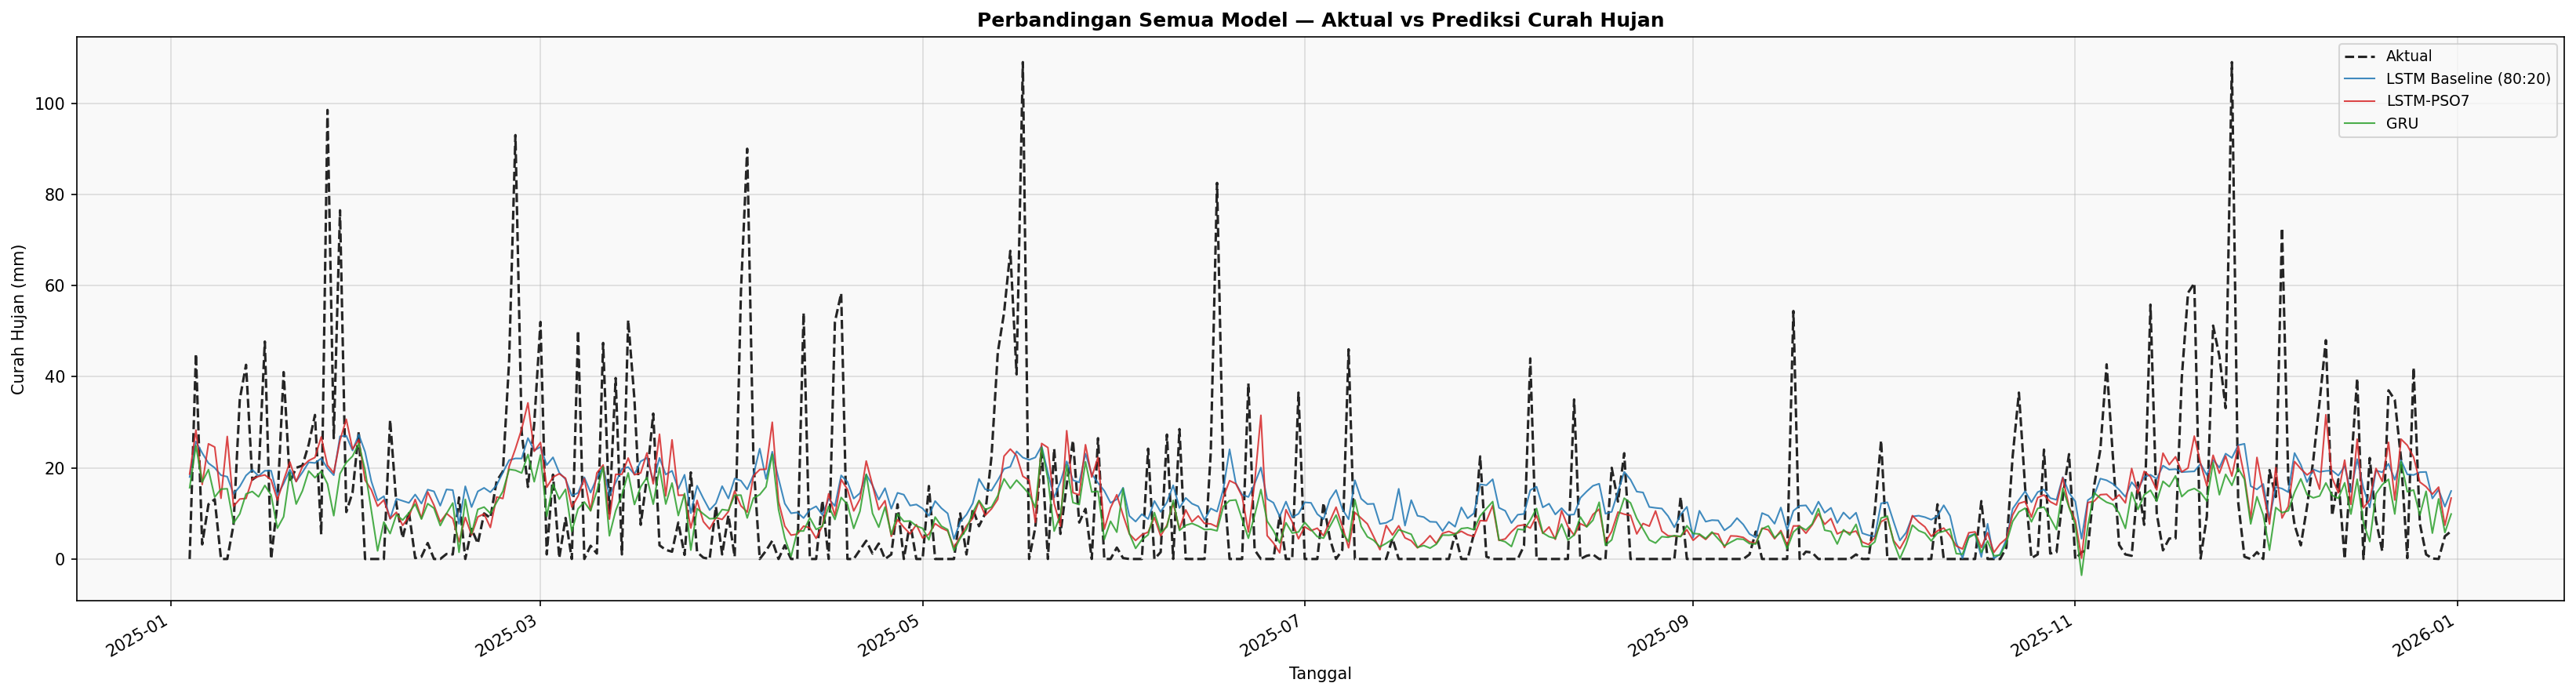

In [44]:
plt.figure(figsize=(22, 6))
plt.plot(d_te80, actual_80mm, label='Aktual', color='black',
         linewidth=1.5, linestyle='--', alpha=0.85)

best_pso_name = best_pso['Model']
pso_pred_map  = {
    'LSTM-PSO1': pred_pso1, 'LSTM-PSO2': pred_pso2,
    'LSTM-PSO3': pred_pso3, 'LSTM-PSO4': pred_pso4,
    'LSTM-PSO5': pred_pso5, 'LSTM-PSO6': pred_pso6,
    'LSTM-PSO7': pred_pso7, 'LSTM-PSO8': pred_pso8,
    'LSTM-PSO9': pred_pso9, 'LSTM-PSO10': pred_pso10
}
best_pso_pred = pso_pred_map[best_pso_name]

colors = ['#1f77b4','#d62728','#2ca02c','#ff7f0e']
preds  = [
    ('LSTM Baseline (80:20)', pred_bl80, colors[0]),
    (best_pso_name,           best_pso_pred, colors[1]),
    ('GRU',                   pred_gru,  colors[2]),
]
for name, pred, color in preds:
    plt.plot(d_te80, pred, label=name, color=color, linewidth=1.0, alpha=0.85)

plt.title('Perbandingan Semua Model — Aktual vs Prediksi Curah Hujan',
          fontsize=12, fontweight='bold')
plt.xlabel('Tanggal'); plt.ylabel('Curah Hujan (mm)')
plt.legend(loc='upper right', fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'perbandingan_semua_model.png'), bbox_inches='tight')
plt.show()


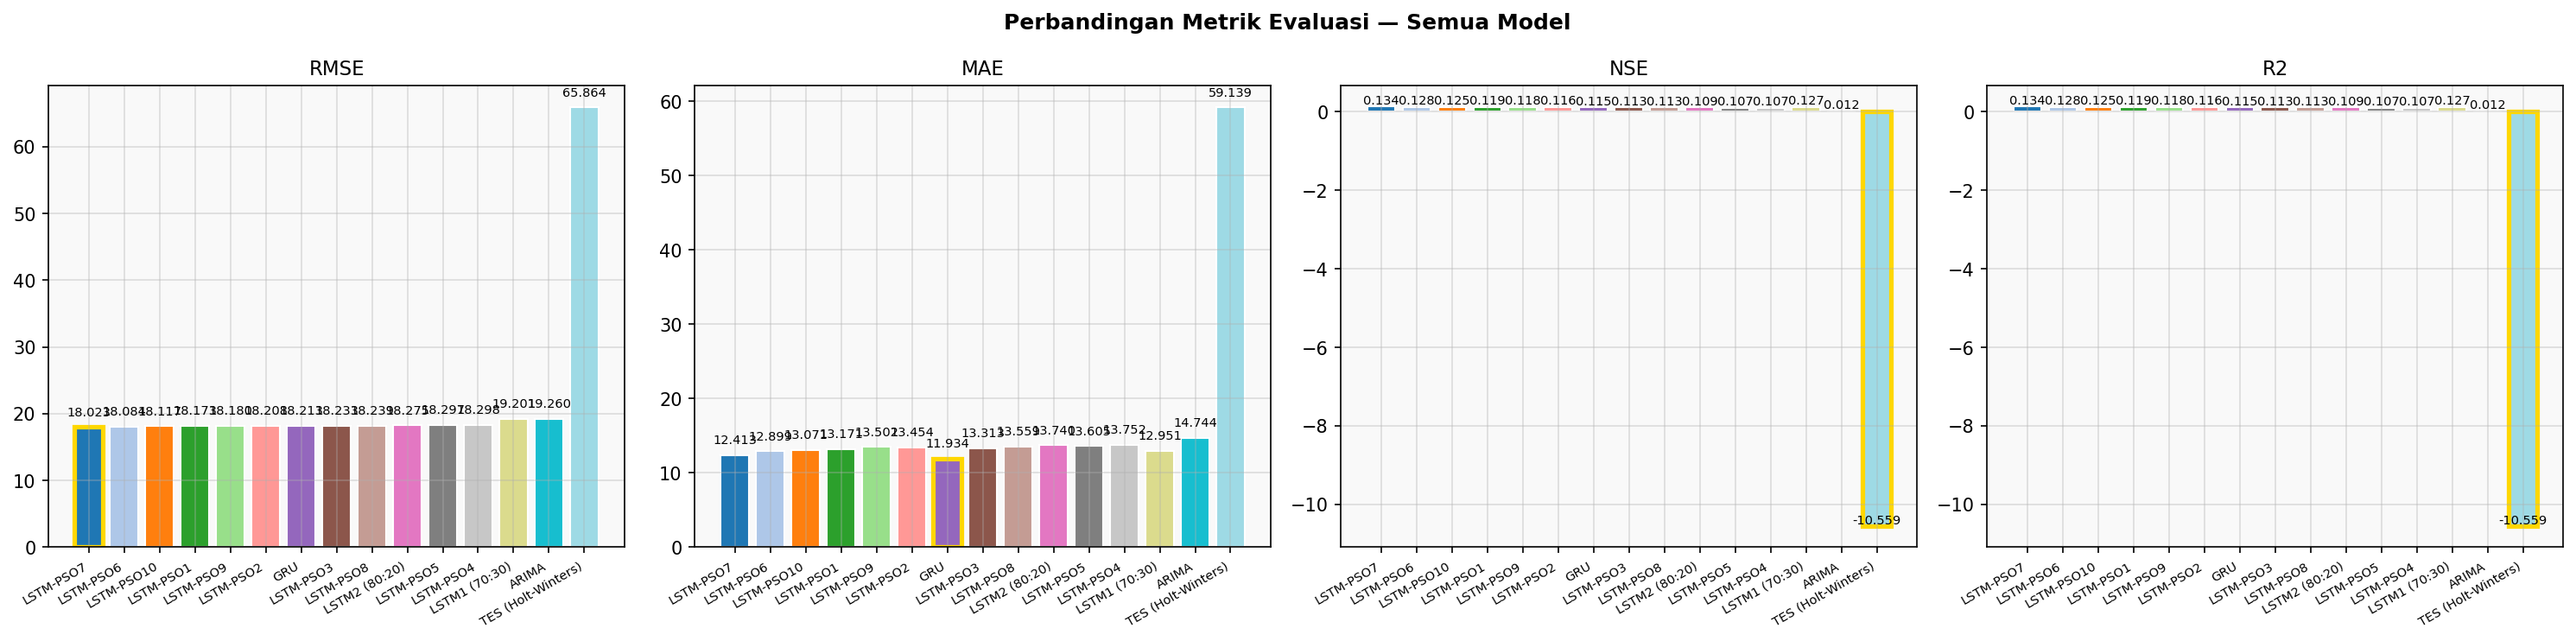

In [45]:
metrics_plot = ['RMSE','MAE','NSE','R2']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Perbandingan Metrik Evaluasi — Semua Model',
             fontsize=12, fontweight='bold')
cmap    = plt.cm.get_cmap('tab20', len(df_final))
palette = [cmap(i) for i in range(len(df_final))]
for ax, metric in zip(axes, metrics_plot):
    vals  = df_final[metric].tolist()
    names = df_final.index.tolist()
    bars  = ax.bar(names, vals, color=palette, edgecolor='white')
    ax.set_title(metric, fontsize=11)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=7)
    best = vals.index(min(vals))
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'bar_chart_metrik.png'), bbox_inches='tight')
plt.show()

In [46]:
print('  RINGKASAN WAKTU KOMPUTASI')
for key, t in timing.items():
    m = int(t // 60); s = t % 60
    print(f'  {key:<30}: {m} mnt {s:.0f} dtk')

df_final.reset_index().to_csv(
    os.path.join(SAVE_DIR, 'hasil_evaluasi_semua_model.csv'), index=False)
df_pso.to_csv(os.path.join(SAVE_DIR, 'pso_skenario_log.csv'), index=False)
print(f'\nSemua file disimpan di: {SAVE_DIR}')

print()
print('Status checkpoint akhir:')
ckpt_list()

  RINGKASAN WAKTU KOMPUTASI
  LSTM1 (70:30)                 : 0 mnt 27 dtk
  LSTM2 (80:20)                 : 0 mnt 34 dtk
  LSTM-PSO1                     : 50 mnt 49 dtk
  LSTM-PSO2                     : 36 mnt 6 dtk
  LSTM-PSO3                     : 59 mnt 58 dtk
  LSTM-PSO4                     : 76 mnt 39 dtk
  LSTM-PSO5                     : 91 mnt 28 dtk
  LSTM-PSO6                     : 105 mnt 32 dtk
  LSTM-PSO7                     : 146 mnt 6 dtk
  LSTM-PSO8                     : 427 mnt 49 dtk
  LSTM-PSO9                     : 219 mnt 14 dtk
  LSTM-PSO10                    : 626 mnt 49 dtk
  ARIMA                         : 0 mnt 0 dtk
  TES                           : 0 mnt 1 dtk
  GRU                           : 4 mnt 3 dtk

Semua file disimpan di: d:\\rainfall-forecasting\\output_pengujian

Status checkpoint akhir:
  Checkpoint ditemukan: d:\\rainfall-forecasting\\output_pengujian\checkpoint.pkl
  Total key tersimpan : 26
    - LSTM1_70
    - LSTM2_80
    - PSO1
    - m_PSO1


In [47]:
# ── Tampilkan hasil evaluasi setiap model ──────────────────────────
print("=" * 52)
print("  HASIL EVALUASI SETIAP MODEL")
print("=" * 52)

for model_name, row in df_final.iterrows():
    print(f"\n  Model : {model_name}")
    print(f"  RMSE  : {row['RMSE']:.4f}")
    print(f"  MAE   : {row['MAE']:.4f}")
    print(f"  NSE   : {row['NSE']:.4f}")
    print(f"  R²    : {row['R2']:.4f}")
    print(f"  {'-' * 34}")

best = df_final.index[0]
print(f"\n  Model terbaik (RMSE terkecil): {best}")
print(f"  RMSE : {df_final.loc[best, 'RMSE']:.4f}")
print(f"  MAE  : {df_final.loc[best, 'MAE']:.4f}")
print(f"  NSE  : {df_final.loc[best, 'NSE']:.4f}")
print(f"  R²   : {df_final.loc[best, 'R2']:.4f}")
print("=" * 52)

  HASIL EVALUASI SETIAP MODEL

  Model : LSTM-PSO7
  RMSE  : 18.0230
  MAE   : 12.4126
  NSE   : 0.1336
  R²    : 0.1336
  ----------------------------------

  Model : LSTM-PSO6
  RMSE  : 18.0841
  MAE   : 12.8988
  NSE   : 0.1277
  R²    : 0.1277
  ----------------------------------

  Model : LSTM-PSO10
  RMSE  : 18.1173
  MAE   : 13.0710
  NSE   : 0.1245
  R²    : 0.1245
  ----------------------------------

  Model : LSTM-PSO1
  RMSE  : 18.1727
  MAE   : 13.1709
  NSE   : 0.1192
  R²    : 0.1192
  ----------------------------------

  Model : LSTM-PSO9
  RMSE  : 18.1802
  MAE   : 13.5021
  NSE   : 0.1184
  R²    : 0.1184
  ----------------------------------

  Model : LSTM-PSO2
  RMSE  : 18.2085
  MAE   : 13.4535
  NSE   : 0.1157
  R²    : 0.1157
  ----------------------------------

  Model : GRU
  RMSE  : 18.2130
  MAE   : 11.9341
  NSE   : 0.1153
  R²    : 0.1153
  ----------------------------------

  Model : LSTM-PSO3
  RMSE  : 18.2331
  MAE   : 13.3128
  NSE   : 0.1133
  R² 